| RA | Nome |
|---|---|
| 210036 | Gustavo Tambelli Rodrigues  |
| 210052 | João Pedro Santos Batista |
| 210095 | João Vitor Michel Silva |
| 210135 | Lucas Garcia Fragoso |
| 210395 | Gabriel Coelho Crispi |
| 210417 | Joao Camillo De Moura |
| 210475 | Guilherme Siqueira De Grado Pereira |
| 212177 | Henrique Jacinto Blezins De Araujo |
| 222312 | Heloísa Goulart Vicencio |
| 224154 | Lucas Henrique Rocha |

## Sites interessantes:
- Aplicação da Yolo v9 para detectar EPI: https://www.kaggle.com/code/hinepo/yolov8-finetuning-for-ppe-detection
- Aplicação de Redzone para detectar EPI: https://www.kaggle.com/code/hinepo/yolov8-inference-for-red-zone-application
- Dataset: https://www.kaggle.com/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow

# Tema: Monitoramento Automático Do Uso de EPIs
## Objetivo:
- Desenvolver um sistema baseado em visão computacional para identificar, em tempo real, a presença e o uso correto de Equipamentos de Proteção Individual (EPIs) por colaboradores em ambientes industriais, visando conformidade com normas de segurança e mitigação de riscos operacionais.

## Motivação e Relevância
- Aumentar o controle de conformidade das  NRs prevenindo acidentes de trabalho e reduzindo passivos legais relacionados;
- Relevante para ambientes com alta rotatividade de pessoal, zonas de risco operacional e setores com demanda de rastreamento contínuo de segurança do trabalhador.

## Descrição do Problema
- Ambientes controlados e/ou zonas de risco operacional com fluxo constante de colaboradores, onde o uso obrigatório de EPIs é exigido, como capacetes, óculos de proteção, luvas, coletes refletivos, máscaras, protetores auriculares, etc. - O sistema deve operar de forma contínua, realizando a verificação visual automática, considerando a movimentação natural dos trabalhadores, com diferentes posturas e orientações corporais.

## Requisitos
- Diferentes tipos de EPIs com variações visuais: capacetes (diferentes cores conforme função), coletes refletivos, máscaras faciais, óculos de proteção, luvas em cores diversas, calçados de segurança, etc.
- Variação no posicionamento dos itens no corpo (inclinado, parcialmente exposto, etc)
- Tipos de uniforme (camisa, jaleco, macacão).

## Caracteristicas Ambiente
- Iluminação variável;
- Sobreamento;
- Reflexo;
- Ruido visual (falsos positivo);
- Fluxo intenso de pessoas, maquinas, veiculos, causando oclusão parcial.

## Restrições
- Capacidade computacional (sistema embarcado);
- Otimização de modelos para inferência eficiente;
- Protocolo de comunicação para análise em tempo real (Edge).
- NOTA: Ele confirmou em sala que esse aspecto não vai ser cobrado, talvez seja melhor confirmar com ele se isso aqui vai manter como nossa restrição ou se vai ter outra.

## Aplicabilidade Cenários Industrial
- Segurança do Trabalho;
- Controle de acesso inteligente;
- Monitoramento em áreas de risco (multisetorial);
- Automação de conformidade das NRs;
- Segurança patrimonial e compliance operacional;
- Escalabilidade (multisetorial e itens diversos);
- Industria 4.0.

## Exemplos de indústrias para aplicar
- Construção civil / obras de grande porte (capacete, colete, bota).
- Usinas hidrelétricas / termoelétricas (NR-10).
- Mineração (capacete, luvas, máscarao).
- Indústria petroquímica / refinarias (ambientes críticos, explosivos, muito fiscalizado).
- Logística & Armazéns (Correios, transportadoras, centros de distribuição) (colete refletivo, capacete em docas, calçado).
## Dentre elas, destaco Construção civil
- Ambiente de alto risco, exigência clara de capacete/coleto/bota.
- Detectar capacete/colete/bota é mais simples que, por exemplo, protetor auricular ou máscara transparente.

# Desenvolvimento

In [1]:
!pip install --upgrade pip
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install ultralytics==8.3.12
!pip install roboflow==1.2.10
!pip install opencv-python-headless==4.10.0.84

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.0/871.0 kB 34.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ultralytics]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 172.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.2 MB/s  0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstal

In [2]:
!pip install -q roboflow kaggle

In [3]:
from google.colab import files
print("Upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d snehilsanyal/construction-site-safety-image-dataset-roboflow -q
!unzip -q construction-site-safety-image-dataset-roboflow.zip -d dataset
!ls -R dataset | sed -n '1,200p'

Upload kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow
License(s): Attribution 4.0 International (CC BY 4.0)
dataset:
css-data
results_yolov8n_100e
source_files

dataset/css-data:
README.dataset.txt
README.roboflow.txt
test
train
valid

dataset/css-data/test:
images
labels

dataset/css-data/test/images:
000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg
002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg
003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg
004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg
004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg
006463_jpg.rf.02f19082420ecc5537b9d59abbe6050c.jpg
006672_jpg.rf.87d5978c486feb53177408cf00a0d87f.jpg
0_jpg.rf.2ff49f74309118f169e07aa12564df87.jpg
2008_008320_jpg.rf.bd34011d46f82f9410d95f00e560b8ea.jpg
2008_008519_jpg.rf.1798c8eed7de04399a0e7e297b4b4c9e.jpg
2009_000059_jpg.rf.50e8398a37eb33f33fd9f662feeea083.jpg
2009_000496_jpg.rf.9a2d210fe0f5ea4b572a

## Inspecionando pastas e mostrando imagens

dataset 0


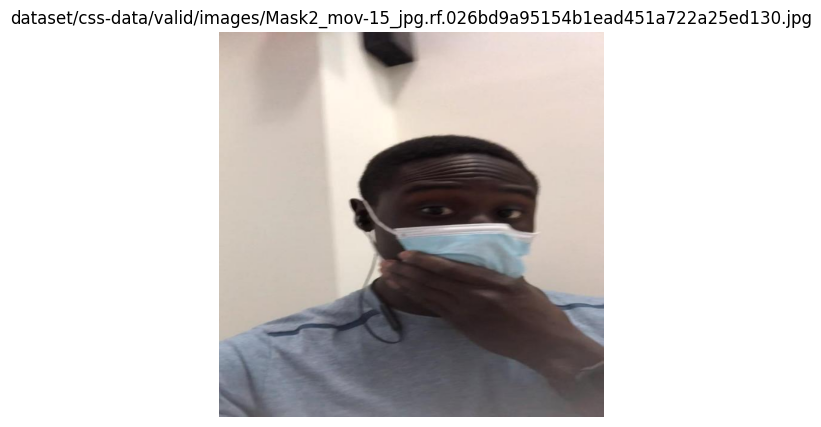

In [4]:
import os, random, glob, matplotlib.pyplot as plt, cv2
dataset_root = "dataset"

for root, dirs, files in os.walk(dataset_root):
    print(root, len(files))
    break

img_files = glob.glob(os.path.join(dataset_root, "**", "*.jpg"), recursive=True) + glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)
if img_files:
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,5))
    plt.imshow(img)
    plt.title(img_path)
    plt.axis('off')
else:
    print("Imagens não encontradas")

In [5]:
import json, os, shutil
from pathlib import Path

coco_ann = None
for j in glob.glob(os.path.join(dataset_root, "**", "*.json"), recursive=True):
    with open(j,'r',encoding='utf-8') as f:
        data = json.load(f)
        if 'annotations' in data and 'images' in data:
            coco_ann = data
            ann_path = j
            break

if coco_ann is None:
    print("COCO não encontrado")
else:
    print("COCO JSON:", ann_path)
    out_labels = Path("yolo_labels")
    if out_labels.exists():
        shutil.rmtree(out_labels)
    out_labels.mkdir(parents=True, exist_ok=True)
    img_map = {img['id']: img for img in coco_ann['images']}
    cats = {c['id']: c['name'] for c in coco_ann['categories']}
    class_names = sorted(list(set(cats.values())))
    cat_to_idx = {name: i for i, name in enumerate(class_names)}
    anns_by_img = {}
    for ann in coco_ann['annotations']:
        anns_by_img.setdefault(ann['image_id'], []).append(ann)
    for img_id, anns in anns_by_img.items():
        img_info = img_map[img_id]
        w, h = img_info['width'], img_info['height']
        lines = []
        for ann in anns:
            catname = cats[ann['category_id']]
            cls = cat_to_idx[catname]
            x, y, bw, bh = ann['bbox']
            x_c = x + bw/2
            y_c = y + bh/2
            lines.append(f"{cls} {x_c/w:.6f} {y_c/h:.6f} {bw/w:.6f} {bh/h:.6f}")
        img_fname = Path(img_info['file_name']).stem
        with open(out_labels / f"{img_fname}.txt", "w") as f:
            f.write("\n".join(lines))
    data_yaml = {
        'path': os.path.abspath(dataset_root),
        'train': '', 'val': '', 'test': '',
        'names': class_names
    }
    import yaml
    with open('data.yaml','w') as f:
        yaml.dump(data_yaml)
    print("Rótulos YOLO criados em 'yolo_labels' e esqueleto data.yaml criado.")

COCO não encontrado


## Preparar data.yaml para o Ultralytics (treinamento YOLO)

In [6]:
import os

current_dir = os.getcwd()
dataset_absolute_path = os.path.join(current_dir, "dataset", "css-data-filtered")

data_yaml_text = f"""
path: {dataset_absolute_path}
train: train/images
val: valid/images
test: test/images

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Vest

nc: 7
"""

with open('data.yaml', 'w') as f:
    f.write(data_yaml_text.strip())

print("✓ data.yaml criado com sucesso!")
print(f"\nCaminho do dataset: {dataset_absolute_path}")
print("\nClasses (7 classes - apenas EPIs):")
print("  0: Hardhat")
print("  1: Mask")
print("  2: NO-Hardhat")
print("  3: NO-Mask")
print("  4: NO-Safety Vest")
print("  5: Person")
print("  6: Safety Vest")

✓ data.yaml criado com sucesso!

Caminho do dataset: /content/dataset/css-data-filtered

Classes (7 classes - apenas EPIs):
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Vest


In [9]:
import os
import shutil
from pathlib import Path

print("=" * 60)
print("FILTRAGEM DO DATASET")
print("=" * 60)

CLASSES_TO_REMOVE = {6, 8, 9}

CLASS_REMAP = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    7: 6,
}

dataset_path = "./dataset/css-data"
filtered_path = "./dataset/css-data-filtered"

for split in ['train', 'valid', 'test']:
    Path(filtered_path, split, 'images').mkdir(parents=True, exist_ok=True)
    Path(filtered_path, split, 'labels').mkdir(parents=True, exist_ok=True)

total_images_kept = 0
total_images_removed = 0
total_annotations_original = 0
total_annotations_removed = 0
total_annotations_kept = 0

for split in ['train', 'valid', 'test']:
    src_img_dir = Path(dataset_path, split, 'images')
    src_lbl_dir = Path(dataset_path, split, 'labels')
    dst_img_dir = Path(filtered_path, split, 'images')
    dst_lbl_dir = Path(filtered_path, split, 'labels')

    if not src_lbl_dir.exists():
        print(f"Aviso: {src_lbl_dir} não encontrado")
        continue

    split_kept = 0
    split_removed = 0

    for label_file in src_lbl_dir.glob('*.txt'):
        filtered_lines = []
        annotations_in_file = 0

        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    annotations_in_file += 1
                    total_annotations_original += 1
                    cls_id = int(parts[0])

                    if cls_id in CLASSES_TO_REMOVE:
                        total_annotations_removed += 1
                        continue

                    new_cls_id = CLASS_REMAP.get(cls_id, cls_id)
                    new_line = f"{new_cls_id} {' '.join(parts[1:])}\n"
                    filtered_lines.append(new_line)
                    total_annotations_kept += 1

        if len(filtered_lines) > 0:
            img_name = label_file.stem + '.jpg'
            src_img = src_img_dir / img_name

            if src_img.exists():
                shutil.copy2(src_img, dst_img_dir / img_name)

                with open(dst_lbl_dir / label_file.name, 'w') as f:
                    f.writelines(filtered_lines)

                total_images_kept += 1
                split_kept += 1
            else:
                print(f"Aviso: Imagem {img_name} não encontrada")
        else:
            total_images_removed += 1
            split_removed += 1

    print(f"\n{split.upper()}:")
    print(f"  Imagens mantidas: {split_kept}")
    print(f"  Imagens removidas: {split_removed}")

print("\n" + "=" * 60)
print("RESUMO DA FILTRAGEM")
print("=" * 60)
print(f"Total de imagens mantidas: {total_images_kept}")
print(f"Total de imagens removidas: {total_images_removed}")
print(f"\nTotal de anotações originais: {total_annotations_original}")
print(f"Anotações removidas (classes 6,8,9): {total_annotations_removed}")
print(f"Anotações mantidas: {total_annotations_kept}")
print(f"\nDataset filtrado salvo em: {filtered_path}")
print("\n✓ Filtragem concluída com sucesso!")

FILTRAGEM DO DATASET

TRAIN:
  Imagens mantidas: 2536
  Imagens removidas: 69

VALID:
  Imagens mantidas: 84
  Imagens removidas: 30

TEST:
  Imagens mantidas: 60
  Imagens removidas: 22

RESUMO DA FILTRAGEM
Total de imagens mantidas: 2680
Total de imagens removidas: 121

Total de anotações originais: 38352
Anotações removidas (classes 6,8,9): 10476
Anotações mantidas: 27876

Dataset filtrado salvo em: ./dataset/css-data-filtered

✓ Filtragem concluída com sucesso!


In [10]:
import os

dataset_path = "/content/dataset/css-data"
splits = ['train', 'valid', 'test']

print("=" * 60)
print("ESTRUTURA DO DATASET")
print("=" * 60)

for split in splits:
    img_path = os.path.join(dataset_path, split, 'images')
    lbl_path = os.path.join(dataset_path, split, 'labels')

    n_images = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    n_labels = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0

    print(f"\n{split.upper()}:")
    print(f"  Imagens: {n_images}")
    print(f"  Labels:  {n_labels}")

    if n_images != n_labels:
        print(f"  ⚠️ ATENÇÃO: Número de imagens e labels diferente!")

print("\n" + "=" * 60)

ESTRUTURA DO DATASET

TRAIN:
  Imagens: 2605
  Labels:  2605

VALID:
  Imagens: 114
  Labels:  114

TEST:
  Imagens: 82
  Labels:  82



## Análise Exploratória do Dataset

ANÁLISE EXPLORATÓRIA - DISTRIBUIÇÃO DE CLASSES


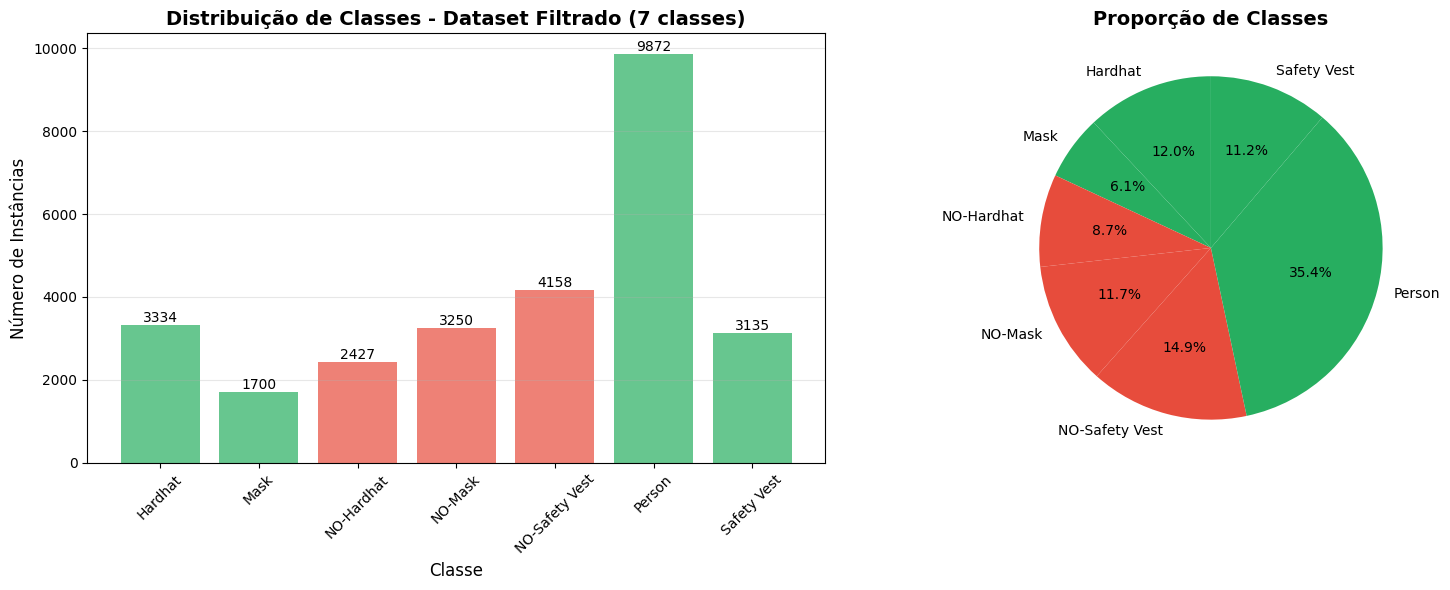


Total de anotações: 27876

Distribuição por classe:
  Hardhat             :  3334 ( 12.0%)
  Mask                :  1700 (  6.1%)
  NO-Hardhat          :  2427 (  8.7%)
  NO-Mask             :  3250 ( 11.7%)
  NO-Safety Vest      :  4158 ( 14.9%)
  Person              :  9872 ( 35.4%)
  Safety Vest         :  3135 ( 11.2%)

✓ Gráfico salvo em 'eda_distribuicao_filtrado.png'


In [11]:
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("ANÁLISE EXPLORATÓRIA - DISTRIBUIÇÃO DE CLASSES")
print("=" * 60)

class_names = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Vest'
}

dataset_path = "./dataset/css-data-filtered"
class_counts = {i: 0 for i in range(7)}

for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(dataset_path, split, 'labels')
    if os.path.exists(label_dir):
        for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        if cls_id in class_counts:
                            class_counts[cls_id] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

classes = [class_names[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]
colors = ['#e74c3c' if 'NO' in name else '#27ae60' for name in classes]

bars = ax1.bar(classes, counts, color=colors, alpha=0.7)
ax1.set_xlabel('Classe', fontsize=12)
ax1.set_ylabel('Número de Instâncias', fontsize=12)
ax1.set_title('Distribuição de Classes - Dataset Filtrado (7 classes)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

ax2.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Proporção de Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribuicao_filtrado.png', dpi=150, bbox_inches='tight')
plt.show()

total_annotations = sum(counts)
print(f"\nTotal de anotações: {total_annotations}")
print(f"\nDistribuição por classe:")
for cls_id in sorted(class_counts.keys()):
    count = class_counts[cls_id]
    percentage = (count / total_annotations * 100) if total_annotations > 0 else 0
    print(f"  {class_names[cls_id]:20s}: {count:5d} ({percentage:5.1f}%)")

print("\n✓ Gráfico salvo em 'eda_distribuicao_filtrado.png'")

VISUALIZAÇÃO DE EXEMPLOS POR CLASSE


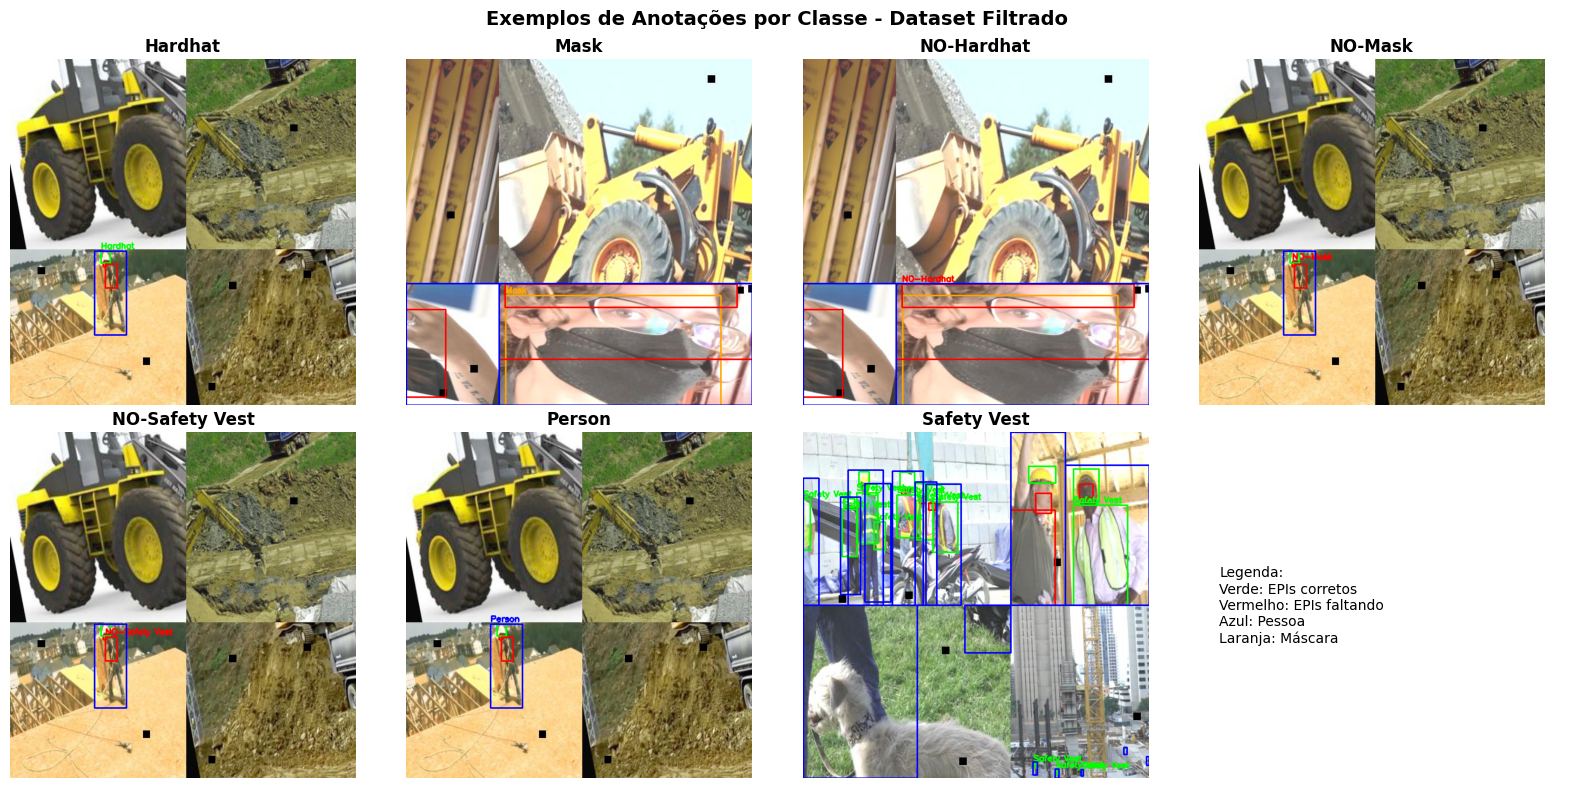


✓ Gráfico salvo em 'exemplos_anotados_filtrado.png'


In [12]:
import cv2
import random
import matplotlib.pyplot as plt
import glob
import os

class_names = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Vest'
}

class_colors = {
    0: (0, 255, 0),
    1: (255, 165, 0),
    2: (255, 0, 0),
    3: (255, 0, 0),
    4: (255, 0, 0),
    5: (0, 0, 255),
    6: (0, 255, 0),
}

print("=" * 60)
print("VISUALIZAÇÃO DE EXEMPLOS POR CLASSE")
print("=" * 60)

dataset_path = "./dataset/css-data-filtered/train"
image_dir = os.path.join(dataset_path, "images")
label_dir = os.path.join(dataset_path, "labels")

examples = {i: None for i in range(7)}

label_files = glob.glob(os.path.join(label_dir, "*.txt"))
random.shuffle(label_files)

for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                if cls_id in examples and examples[cls_id] is None:
                    img_name = os.path.basename(label_file).replace('.txt', '.jpg')
                    img_path = os.path.join(image_dir, img_name)
                    if os.path.exists(img_path):
                        examples[cls_id] = (img_path, label_file)

    if all(v is not None for v in examples.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(examples.keys())):
    ax = axes[idx]

    if examples[cls_id] is not None:
        img_path, label_path = examples[cls_id]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    c = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])

                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)

                    color = class_colors.get(c, (255, 255, 255))
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                    if c == cls_id:
                        cv2.putText(img, class_names[c], (x1, y1-5),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        ax.imshow(img)
        ax.set_title(f'{class_names[cls_id]}', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Sem exemplo', ha='center', va='center')
        ax.set_title(f'{class_names[cls_id]}', fontweight='bold')

    ax.axis('off')

axes[-1].axis('off')

legend_text = "Legenda:\n"
legend_text += "Verde: EPIs corretos\n"
legend_text += "Vermelho: EPIs faltando\n"
legend_text += "Azul: Pessoa\n"
legend_text += "Laranja: Máscara"
axes[-1].text(0.1, 0.5, legend_text, fontsize=10, verticalalignment='center')

plt.suptitle('Exemplos de Anotações por Classe - Dataset Filtrado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exemplos_anotados_filtrado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo em 'exemplos_anotados_filtrado.png'")

---

# Treinamento dos Modelos

## Configurações Comuns
- **Epochs:** 50 (para comparação justa)
- **Batch Size:** 16
- **Image Size:** 640x640
- **Optimizer:** AdamW (YOLO) / SGD (Faster R-CNN)
- **Learning Rate:** 0.001

---

## 1. Treinamento YOLOv8

In [15]:
import torch

print("=" * 60)
print("CONFIGURAÇÃO DE HARDWARE")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

EPOCHS = 50
BATCH_SIZE = 16
IMG_SIZE = 640
PATIENCE = 25
SEED = 42

DROPOUT = 0.025
WEIGHT_DECAY = 0.0005
LR0 = 0.001
LRF = 0.01

print(f"\n{'=' * 60}")
print("HIPERPARÂMETROS (OTIMIZADOS)")
print("=" * 60)
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Early Stopping Patience: {PATIENCE}")
print(f"Random Seed: {SEED}")
print(f"Dropout: {DROPOUT}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Learning Rate (lr0): {LR0}")
print(f"LR Factor (lrf): {LRF}")

CONFIGURAÇÃO DE HARDWARE
PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: NVIDIA L4
CUDA memory: 23.8 GB

HIPERPARÂMETROS (OTIMIZADOS)
Epochs: 50
Batch Size: 16
Image Size: 640x640
Early Stopping Patience: 25
Random Seed: 42
Dropout: 0.025
Weight Decay: 0.0005
Learning Rate (lr0): 0.001
LR Factor (lrf): 0.01


In [16]:
from ultralytics import YOLO
import time

print("=" * 60)
print("TREINAMENTO YOLOv8 (OTIMIZADO)")
print("=" * 60)

model_yolov8 = YOLO('yolov8s.pt')

start_time = time.time()

results_yolov8 = model_yolov8.train(
    data='data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    seed=SEED,
    project='yolov8',
    name='train_optimized',
    exist_ok=True,
    verbose=True,
    plots=True,
    save=True,
    save_period=10,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=4,

    optimizer='auto',
    lr0=LR0,
    lrf=LRF,
    weight_decay=WEIGHT_DECAY,

    dropout=DROPOUT,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
)

yolov8_train_time = time.time() - start_time
print(f"\n✓ Treinamento YOLOv8 (otimizado) concluído em {yolov8_train_time/60:.1f} minutos")

TREINAMENTO YOLOv8 (OTIMIZADO)
New https://pypi.org/project/ultralytics/8.3.231 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=data.yaml, epochs=50, time=None, patience=25, batch=16, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=4, project=yolov8, name=train_optimized, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.025, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None

train: Scanning /content/dataset/css-data-filtered/train/labels.cache... 2536 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2536/2536 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/dataset/css-data-filtered/valid/labels.cache... 84 images, 0 backgrounds, 0 corrupt: 100%|██████████| 84/84 [00:00<?, ?it/s]


Plotting labels to yolov8/train_optimized/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000909, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to yolov8/train_optimized
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


50 epochs completed in 0.392 hours.
Optimizer stripped from yolov8/train_optimized/weights/last.pt, 19.9MB
Optimizer stripped from yolov8/train_optimized/weights/best.pt, 19.9MB

Validating yolov8/train_optimized/weights/best.pt...
Ultralytics 8.3.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 186 layers, 9,830,373 parameters, 0 gradients, 23.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.88it/s]


                   all         84        556      0.912       0.75       0.83      0.509
               Hardhat         42         79      0.967      0.785      0.886      0.562
                  Mask         19         21      0.948      0.905      0.938      0.621
            NO-Hardhat         37         69      0.819      0.594      0.714      0.415
               NO-Mask         44         74      0.863      0.676      0.706      0.378
        NO-Safety Vest         56        106      0.957      0.698      0.806      0.475
                Person         84        166      0.906      0.765       0.86      0.518
           Safety Vest         28         41      0.926      0.829      0.902      0.592
Speed: 0.2ms preprocess, 4.9ms inference, 0.0ms loss, 9.8ms postprocess per image
Results saved to yolov8/train_optimized


lr/pg0,▃▆█████▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆█████▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,▃▆█████▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▁▂▃▂▄▅▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
metrics/mAP50-95(B),▂▁▂▃▂▄▃▄▃▄▄▄▅▅▄▅▅▅▅▅▆▆▆▆▇▇▇▆▇▇▇▇▇▇▇█▇███
metrics/precision(B),▃▁▁▄▃▄▅▅▇▅▅▆▆▇▆▆▇▇▇▇▆▇█▇▇▇▇▇▇▆▇▇███▇████
metrics/recall(B),▁▁▂▃▃▄▄▆▅▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇██████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



✓ Treinamento YOLOv8 (otimizado) concluído em 23.9 minutos


In [18]:
print("=" * 60)
print("AVALIAÇÃO YOLOv8 NO CONJUNTO DE TESTE")
print("=" * 60)

best_yolov8 = YOLO('yolov8/train_optimized/weights/best.pt')

metrics_yolov8 = best_yolov8.val(
    data='data.yaml',
    split='test',
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=0 if torch.cuda.is_available() else 'cpu',
    plots=True,
    save_json=True,
)

yolov8_results = {
    'model': 'YOLOv8n',
    'mAP50': metrics_yolov8.box.map50,
    'mAP50-95': metrics_yolov8.box.map,
    'precision': metrics_yolov8.box.mp,
    'recall': metrics_yolov8.box.mr,
    'f1_score': 2 * (metrics_yolov8.box.mp * metrics_yolov8.box.mr) / (metrics_yolov8.box.mp + metrics_yolov8.box.mr + 1e-6),
}

print(f"\nResultados YOLOv8:")
for key, value in yolov8_results.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

AVALIAÇÃO YOLOv8 NO CONJUNTO DE TESTE
Ultralytics 8.3.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 186 layers, 9,830,373 parameters, 0 gradients, 23.4 GFLOPs


val: Scanning /content/dataset/css-data-filtered/test/labels... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<00:00, 1413.29it/s]

val: New cache created: /content/dataset/css-data-filtered/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]


                   all         60        583      0.918      0.751      0.816      0.476
               Hardhat         30        110      0.969      0.856      0.941      0.577
                  Mask         16         28       0.94       0.75      0.797      0.472
            NO-Hardhat         25         41      0.817      0.546       0.54      0.324
               NO-Mask         30         79      0.932      0.695      0.801       0.36
        NO-Safety Vest         36         90      0.971      0.756      0.839      0.523
                Person         59        174      0.876      0.822      0.873        0.5
           Safety Vest         22         61      0.924      0.836      0.919      0.576
Speed: 0.4ms preprocess, 8.8ms inference, 0.0ms loss, 2.6ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val

Resultados YOLOv8:
  mAP50: 0.8157
  mAP50-95: 0.4762
  precision: 0.9184
  recall: 0.7514
  f1_score: 0.8266


---

## 2. Treinamento YOLOv11

In [19]:
!pip install -U ultralytics

from ultralytics import YOLO
print(f"Ultralytics version: {__import__('ultralytics').__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.2 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.12
    Uninstalling ultralytics-8.3.12:
      Successfully uninstalled ultralytics-8.3.12


Ultralytics version: 8.3.12


In [ ]:
from ultralytics import YOLO
import time

print("=" * 60)
print("TREINAMENTO YOLOv11 (OTIMIZADO)")
print("=" * 60)

model_yolov11 = YOLO('yolo11s.pt')

start_time = time.time()

results_yolov11 = model_yolov11.train(
    data='data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    seed=SEED,
    project='yolov11',
    name='train_optimized',
    exist_ok=True,
    verbose=True,
    plots=True,
    save=True,
    save_period=10,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=4,

    optimizer='auto',
    lr0=LR0,
    lrf=LRF,
    weight_decay=WEIGHT_DECAY,

    dropout=DROPOUT,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
)

yolov11_train_time = time.time() - start_time
print(f"\n✓ Treinamento YOLOv11 (otimizado) concluído em {yolov11_train_time/60:.1f} minutos")

TREINAMENTO YOLOv11 (OTIMIZADO)


100%|██████████| 18.4M/18.4M [00:00<00:00, 353MB/s]

New https://pypi.org/project/ultralytics/8.3.231 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=data.yaml, epochs=50, time=None, patience=25, batch=16, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=4, project=yolov11, name=train_optimized, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.025, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fals

  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLO11n...
AMP: checks passed ✅


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      16/50      5.73G      1.253      1.173       1.36        134        640: 100%|██████████| 159/159 [00:29<00:00,  5.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  5.14it/s]

                   all         84        556      0.735      0.665      0.702      0.305



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      17/50      4.73G      1.235      1.142      1.343        256        640:  47%|████▋     | 74/159 [00:13<00:15,  5.50it/s]

In [ ]:
print("=" * 60)
print("AVALIAÇÃO YOLOv11 NO CONJUNTO DE TESTE")
print("=" * 60)

best_yolov11 = YOLO('yolov11/train_optimized/weights/best.pt')

metrics_yolov11 = best_yolov11.val(
    data='data.yaml',
    split='test',
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=0 if torch.cuda.is_available() else 'cpu',
    plots=True,
    save_json=True,
)

yolov11_results = {
    'model': 'YOLOv11n',
    'mAP50': metrics_yolov11.box.map50,
    'mAP50-95': metrics_yolov11.box.map,
    'precision': metrics_yolov11.box.mp,
    'recall': metrics_yolov11.box.mr,
    'f1_score': 2 * (metrics_yolov11.box.mp * metrics_yolov11.box.mr) / (metrics_yolov11.box.mp + metrics_yolov11.box.mr + 1e-6),
}

print(f"\nResultados YOLOv11:")
for key, value in yolov11_results.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

AVALIAÇÃO YOLOv11 NO CONJUNTO DE TESTE
Ultralytics 8.3.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 238 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/torch_utils.py:262: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  conv.register_parameter("bias", nn.Parameter(fused_bias))
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/torch_utils.py:267: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not de

                   all         82        760      0.841      0.665      0.715      0.425
               Hardhat         30        110      0.966       0.77      0.895      0.559
                  Mask         16         28       0.97       0.75      0.792      0.491
            NO-Hardhat         25         41      0.732      0.537      0.487      0.286
               NO-Mask         30         79      0.807      0.583      0.654      0.277
        NO-Safety Vest         36         90      0.922      0.667      0.785      0.443
                Person         59        174      0.839      0.724      0.813       0.49
           Safety Cone          8         92      0.743      0.391      0.407      0.177
           Safety Vest         22         61      0.829      0.797      0.858      0.553
             machinery         22         44      0.883      0.818      0.853      0.638
               vehicle         15         41      0.724       0.61       0.61      0.339
Speed: 0.2ms preproce

---

## 3. Treinamento Faster R-CNN

O Faster R-CNN é um modelo de detecção de objetos em dois estágios:
1. **Region Proposal Network (RPN):** Propõe regiões candidatas
2. **Detection Head:** Classifica e refina as bounding boxes

Usaremos a implementação do TorchVision com backbone ResNet50-FPN.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.transforms import functional as F
from PIL import Image
import os
import glob

IMG_SIZE = 640

class PPEDataset(Dataset):
    """Dataset para detecção de EPIs no formato PyTorch"""

    def __init__(self, root_dir, split='train', transforms=None, img_size=640):
        self.root_dir = root_dir
        self.split = split
        self.transforms = transforms
        self.img_size = img_size

        self.img_dir = os.path.join(root_dir, split, 'images')
        self.label_dir = os.path.join(root_dir, split, 'labels')

        self.images = sorted(glob.glob(os.path.join(self.img_dir, '*.jpg')))

        self.num_classes = 8

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size

        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        scale_x = self.img_size / orig_w
        scale_y = self.img_size / orig_h

        label_path = img_path.replace(os.sep + 'images' + os.sep, os.sep + 'labels' + os.sep).replace('.jpg', '.txt')

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        xc, yc, w, h = map(float, parts[1:5])

                        x1 = (xc - w/2) * self.img_size
                        y1 = (yc - h/2) * self.img_size
                        x2 = (xc + w/2) * self.img_size
                        y2 = (yc + h/2) * self.img_size

                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(self.img_size, x2), min(self.img_size, y2)

                        if x2 > x1 and y2 > y1:
                            boxes.append([x1, y1, x2, y2])
                            labels.append(cls_id + 1)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

def get_transform(train=True):
    transforms = []
    transforms.append(T.ToTensor())
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

dataset_path = "./dataset/css-data"
test_dataset = PPEDataset(dataset_path, split='train', transforms=get_transform(train=True), img_size=IMG_SIZE)
print(f"✓ Dataset criado com {len(test_dataset)} imagens de treino")
print(f"  Tamanho das imagens: {IMG_SIZE}x{IMG_SIZE} (igual ao YOLO)")

img, target = test_dataset[0]
print(f"  Shape da imagem: {img.shape}")
print(f"  Número de boxes: {len(target['boxes'])}")
print(f"  Classes presentes: {target['labels'].tolist()}")

✓ Dataset criado com 2605 imagens de treino
  Tamanho das imagens: 640x640 (igual ao YOLO)
  Shape da imagem: torch.Size([3, 640, 640])
  Número de boxes: 12
  Classes presentes: [1, 1, 4, 4, 6, 6, 2, 3, 6, 2, 3, 6]


In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_faster_rcnn_model(num_classes):
    """Cria modelo Faster R-CNN com backbone ResNet50-FPN"""

    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

NUM_CLASSES = 8
model_frcnn = get_faster_rcnn_model(NUM_CLASSES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_frcnn.to(device)

print(f"✓ Faster R-CNN criado com {NUM_CLASSES} classes")
print(f"  Device: {device}")

total_params = sum(p.numel() for p in model_frcnn.parameters())
trainable_params = sum(p.numel() for p in model_frcnn.parameters() if p.requires_grad)
print(f"  Total de parâmetros: {total_params/1e6:.2f}M")
print(f"  Parâmetros treináveis: {trainable_params/1e6:.2f}M")

✓ Faster R-CNN criado com 11 classes
  Device: cuda
  Total de parâmetros: 43.30M
  Parâmetros treináveis: 43.08M


In [ ]:
from tqdm import tqdm
import pandas as pd

def collate_fn(batch):
    """Collate function para batches com diferentes números de boxes"""
    return tuple(zip(*batch))

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """Treina o modelo por uma época"""
    model.train()

    total_loss = 0
    loss_classifier = 0
    loss_box_reg = 0
    loss_objectness = 0
    loss_rpn_box_reg = 0

    pbar = tqdm(data_loader, desc=f'Epoch {epoch+1}')

    for images, targets in pbar:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += losses.item()
        loss_classifier += loss_dict.get('loss_classifier', torch.tensor(0)).item()
        loss_box_reg += loss_dict.get('loss_box_reg', torch.tensor(0)).item()
        loss_objectness += loss_dict.get('loss_objectness', torch.tensor(0)).item()
        loss_rpn_box_reg += loss_dict.get('loss_rpn_box_reg', torch.tensor(0)).item()

        pbar.set_postfix({'loss': f'{losses.item():.4f}'})

    n = len(data_loader)
    return {
        'total_loss': total_loss / n,
        'loss_classifier': loss_classifier / n,
        'loss_box_reg': loss_box_reg / n,
        'loss_objectness': loss_objectness / n,
        'loss_rpn_box_reg': loss_rpn_box_reg / n,
    }

@torch.no_grad()
def evaluate_model(model, data_loader, device):
    """Avalia o modelo no conjunto de validação"""
    model.eval()

    all_predictions = []
    all_targets = []

    for images, targets in tqdm(data_loader, desc='Evaluating'):
        images = list(img.to(device) for img in images)

        predictions = model(images)

        all_predictions.extend(predictions)
        all_targets.extend(targets)

    return all_predictions, all_targets

print("✓ Funções de treinamento definidas")

✓ Funções de treinamento definidas


In [ ]:
from collections import defaultdict
import numpy as np

def calculate_iou(box1, box2):
    """Calcula IoU entre duas bounding boxes"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def calculate_ap(recalls, precisions):
    """Calcula Average Precision usando interpolação de 11 pontos"""
    recalls = np.concatenate(([0.], recalls, [1.]))
    precisions = np.concatenate(([0.], precisions, [0.]))

    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    indices = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[indices + 1] - recalls[indices]) * precisions[indices + 1])

    return ap

def calculate_metrics(predictions, targets, iou_threshold=0.5, num_classes=8):
    """Calcula Precision, Recall e mAP para detecção de objetos"""

    class_predictions = defaultdict(list)
    class_targets = defaultdict(list)

    for pred, target in zip(predictions, targets):
        img_id = target['image_id'].item()

        for i in range(len(target['boxes'])):
            cls = target['labels'][i].item()
            box = target['boxes'][i].cpu().numpy()
            class_targets[cls].append({'box': box, 'img_id': img_id, 'matched': False})

        for i in range(len(pred['boxes'])):
            cls = pred['labels'][i].item()
            score = pred['scores'][i].item()
            box = pred['boxes'][i].cpu().numpy()
            class_predictions[cls].append({'box': box, 'score': score, 'img_id': img_id})

    aps = []
    precisions_all = []
    recalls_all = []

    for cls in range(1, num_classes):
        preds = class_predictions[cls]
        targets_cls = class_targets[cls]

        if len(targets_cls) == 0:
            continue

        preds = sorted(preds, key=lambda x: x['score'], reverse=True)

        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))

        for i, pred in enumerate(preds):
            best_iou = 0
            best_target_idx = -1

            for j, target in enumerate(targets_cls):
                if target['img_id'] == pred['img_id'] and not target['matched']:
                    iou = calculate_iou(pred['box'], target['box'])
                    if iou > best_iou:
                        best_iou = iou
                        best_target_idx = j

            if best_iou >= iou_threshold and best_target_idx >= 0:
                tp[i] = 1
                targets_cls[best_target_idx]['matched'] = True
            else:
                fp[i] = 1

        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)

        recalls = tp_cumsum / len(targets_cls)
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

        ap = calculate_ap(recalls, precisions)
        aps.append(ap)

        if len(precisions) > 0:
            precisions_all.append(precisions[-1])
            recalls_all.append(recalls[-1])

    mAP = np.mean(aps) if aps else 0
    precision = np.mean(precisions_all) if precisions_all else 0
    recall = np.mean(recalls_all) if recalls_all else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return {
        'mAP50': mAP,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

print("✓ Funções de métricas definidas")

✓ Funções de métricas definidas


In [ ]:
import time
import os

print("=" * 60)
print("TREINAMENTO FASTER R-CNN")
print("=" * 60)

dataset_path = "./dataset/css-data"
train_dataset = PPEDataset(dataset_path, split='train', transforms=get_transform(train=True), img_size=IMG_SIZE)
valid_dataset = PPEDataset(dataset_path, split='valid', transforms=get_transform(train=False), img_size=IMG_SIZE)
test_dataset = PPEDataset(dataset_path, split='test', transforms=get_transform(train=False), img_size=IMG_SIZE)

BATCH_SIZE_FRCNN = 12
NUM_WORKERS = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_FRCNN,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE_FRCNN,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_FRCNN,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

print(f"Train: {len(train_dataset)} imagens")
print(f"Valid: {len(valid_dataset)} imagens")
print(f"Test: {len(test_dataset)} imagens")
print(f"\nOtimizações aplicadas:")
print(f"  - Imagens: {IMG_SIZE}x{IMG_SIZE} (igual ao YOLO)")
print(f"  - Batch size: {BATCH_SIZE_FRCNN}")
print(f"  - Num workers: {NUM_WORKERS}")
print(f"  - Pin memory: True")

params = [p for p in model_frcnn.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

os.makedirs('runs/faster_rcnn', exist_ok=True)

start_time = time.time()
history = []
best_map = 0
patience_counter = 0

for epoch in range(EPOCHS):
    train_losses = train_one_epoch(model_frcnn, optimizer, train_loader, device, epoch)
    lr_scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == EPOCHS - 1:
        predictions, targets = evaluate_model(model_frcnn, valid_loader, device)
        val_metrics = calculate_metrics(predictions, targets)

        print(f"\nEpoch {epoch+1}: Train Loss={train_losses['total_loss']:.4f}, "
              f"Val mAP@50={val_metrics['mAP50']:.4f}")

        if val_metrics['mAP50'] > best_map:
            best_map = val_metrics['mAP50']
            torch.save(model_frcnn.state_dict(), 'runs/faster_rcnn/best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        history.append({
            'epoch': epoch + 1,
            **train_losses,
            **val_metrics
        })
    else:
        print(f"Epoch {epoch+1}: Train Loss={train_losses['total_loss']:.4f}")
        history.append({
            'epoch': epoch + 1,
            **train_losses,
        })

    if patience_counter >= PATIENCE // 5:
        print(f"\nEarly stopping na epoch {epoch+1}")
        break

frcnn_train_time = time.time() - start_time
print(f"\n✓ Treinamento Faster R-CNN concluído em {frcnn_train_time/60:.1f} minutos")

history_df = pd.DataFrame(history)
history_df.to_csv('runs/faster_rcnn/training_log.csv', index=False)

TREINAMENTO FASTER R-CNN
Train: 2605 imagens
Valid: 114 imagens
Test: 82 imagens

Otimizações aplicadas:
  - Imagens: 640x640 (igual ao YOLO)
  - Batch size: 12
  - Num workers: 8
  - Pin memory: True


Epoch 1: 100%|██████████| 218/218 [05:23<00:00,  1.49s/it, loss=1.5798]


Epoch 1: Train Loss=2.1228


Epoch 2: 100%|██████████| 218/218 [05:22<00:00,  1.48s/it, loss=1.8158]


Epoch 2: Train Loss=1.5967


...

Epoch 43: Train Loss=1.1687


Epoch 44: 100%|██████████| 218/218 [05:23<00:00,  1.49s/it, loss=0.9291]


Epoch 44: Train Loss=1.1623


Evaluating: 100%|██████████| 10/10 [00:06<00:00,  1.44it/s]



Epoch 45: Train Loss=1.1512, Val mAP@50=0.6899

Early stopping na epoch 45

✓ Treinamento Faster R-CNN concluído em 244.0 minutos


In [ ]:
print("=" * 60)
print("AVALIAÇÃO FASTER R-CNN NO CONJUNTO DE TESTE")
print("=" * 60)

model_frcnn.load_state_dict(torch.load('runs/faster_rcnn/best_model.pth'))
model_frcnn.eval()

predictions, targets = evaluate_model(model_frcnn, test_loader, device)

metrics_50 = calculate_metrics(predictions, targets, iou_threshold=0.5)

map_values = []
for iou in np.arange(0.5, 1.0, 0.05):
    m = calculate_metrics(predictions, targets, iou_threshold=iou)
    map_values.append(m['mAP50'])
map_50_95 = np.mean(map_values)

frcnn_results = {
    'model': 'Faster R-CNN',
    'mAP50': metrics_50['mAP50'],
    'mAP50-95': map_50_95,
    'precision': metrics_50['precision'],
    'recall': metrics_50['recall'],
    'f1_score': metrics_50['f1_score'],
}

print(f"\nResultados Faster R-CNN:")
for key, value in frcnn_results.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

AVALIAÇÃO FASTER R-CNN NO CONJUNTO DE TESTE


Evaluating: 100%|██████████| 7/7 [00:04<00:00,  1.40it/s]



Resultados Faster R-CNN:
  mAP50: 0.6239
  mAP50-95: 0.2992
  precision: 0.1721
  recall: 0.7205
  f1_score: 0.2778


---

# Avaliação Comparativa dos Modelos

Nesta seção, comparamos os 3 modelos utilizando as métricas definidas:

| Métrica | Descrição |
|---------|-----------|
| **mAP@50** | Mean Average Precision com IoU ≥ 0.5 |
| **mAP@50-95** | mAP média com IoU de 0.5 a 0.95 |
| **Precision** | Taxa de detecções corretas |
| **Recall** | Taxa de objetos encontrados |
| **F1-Score** | Média harmônica de Precision e Recall |
| **Estabilidade** | Desvio padrão do mAP nas últimas epochs |
| **Overfitting** | Gap entre train e val loss |
| **Tempo de Inferência** | ms por imagem |
| **Tamanho do Modelo** | MB |
| **Generalização** | Performance no conjunto de teste |

In [ ]:
import time
import os

def measure_inference_time(model, data_loader, device, model_type='yolo', n_warmup=10, n_iterations=50):
    """Mede o tempo médio de inferência por imagem"""

    if model_type == 'yolo':
        images = []
        for img_path in glob.glob('/content/dataset/css-data/test/images/*.jpg')[:n_warmup + n_iterations]:
            images.append(img_path)

        for img in images[:n_warmup]:
            _ = model.predict(img, verbose=False)

        start = time.time()
        for img in images[n_warmup:n_warmup + n_iterations]:
            _ = model.predict(img, verbose=False)
        elapsed = time.time() - start

    else:
        model.eval()
        all_images = []

        for images_batch, _ in data_loader:
            for img in images_batch:
                all_images.append(img.to(device))
            if len(all_images) >= n_warmup + n_iterations:
                break

        with torch.no_grad():
            for img in all_images[:n_warmup]:
                _ = model([img])

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()
        with torch.no_grad():
            for img in all_images[n_warmup:n_warmup + n_iterations]:
                _ = model([img])

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

    return (elapsed / n_iterations) * 1000

def get_model_size(model_path):
    """Retorna o tamanho do modelo em MB"""
    return os.path.getsize(model_path) / (1024 * 1024)

print("=" * 60)
print("MÉTRICAS DE EFICIÊNCIA")
print("=" * 60)

print("\nMedindo tempo de inferência...")

yolov8_inf_time = measure_inference_time(best_yolov8, None, device, model_type='yolo')
print(f"  YOLOv8: {yolov8_inf_time:.2f} ms/imagem")

yolov11_inf_time = measure_inference_time(best_yolov11, None, device, model_type='yolo')
print(f"  YOLOv11: {yolov11_inf_time:.2f} ms/imagem")

frcnn_inf_time = measure_inference_time(model_frcnn, test_loader, device, model_type='frcnn')
print(f"  Faster R-CNN: {frcnn_inf_time:.2f} ms/imagem")

print("\nTamanho dos modelos:")
yolov8_size = get_model_size('yolov8/train/weights/best.pt')
yolov11_size = get_model_size('yolov11/train/weights/best.pt')
frcnn_size = get_model_size('runs/faster_rcnn/best_model.pth')

print(f"  YOLOv8: {yolov8_size:.2f} MB")
print(f"  YOLOv11: {yolov11_size:.2f} MB")
print(f"  Faster R-CNN: {frcnn_size:.2f} MB")

yolov8_results['inference_time_ms'] = yolov8_inf_time
yolov8_results['model_size_mb'] = yolov8_size

yolov11_results['inference_time_ms'] = yolov11_inf_time
yolov11_results['model_size_mb'] = yolov11_size

frcnn_results['inference_time_ms'] = frcnn_inf_time
frcnn_results['model_size_mb'] = frcnn_size

MÉTRICAS DE EFICIÊNCIA

Medindo tempo de inferência...
  YOLOv8: 11.93 ms/imagem
  YOLOv11: 14.16 ms/imagem
  Faster R-CNN: 93.40 ms/imagem

Tamanho dos modelos:
  YOLOv8: 5.37 MB
  YOLOv11: 5.22 MB
  Faster R-CNN: 165.55 MB


In [ ]:
import pandas as pd

print("=" * 60)
print("ANÁLISE DE ESTABILIDADE E OVERFITTING")
print("=" * 60)

def analyze_training_history(results_dir, model_name):
    """Analisa o histórico de treinamento"""
    results_csv = os.path.join(results_dir, 'results.csv')

    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        df.columns = df.columns.str.strip()

        if 'metrics/mAP50(B)' in df.columns:
            last_10_map = df['metrics/mAP50(B)'].tail(10)
            stability = last_10_map.std()
        else:
            stability = None

        if 'train/box_loss' in df.columns and 'val/box_loss' in df.columns:
            train_loss_final = df['train/box_loss'].iloc[-1]
            val_loss_final = df['val/box_loss'].iloc[-1]
            overfitting = (val_loss_final - train_loss_final) / train_loss_final * 100
        else:
            overfitting = None

        return {
            'stability': stability,
            'overfitting': overfitting,
            'df': df
        }
    return None

yolov8_analysis = analyze_training_history('yolov8/train', 'YOLOv8')
if yolov8_analysis:
    yolov8_results['stability'] = yolov8_analysis['stability']
    yolov8_results['overfitting_pct'] = yolov8_analysis['overfitting']
    print(f"\nYOLOv8:")
    print(f"  Estabilidade (std mAP últimas 10 epochs): {yolov8_analysis['stability']:.4f}" if yolov8_analysis['stability'] else "  Estabilidade: N/A")
    print(f"  Overfitting (gap val-train loss): {yolov8_analysis['overfitting']:.2f}%" if yolov8_analysis['overfitting'] else "  Overfitting: N/A")

yolov11_analysis = analyze_training_history('yolov11/train', 'YOLOv11')
if yolov11_analysis:
    yolov11_results['stability'] = yolov11_analysis['stability']
    yolov11_results['overfitting_pct'] = yolov11_analysis['overfitting']
    print(f"\nYOLOv11:")
    print(f"  Estabilidade (std mAP últimas 10 epochs): {yolov11_analysis['stability']:.4f}" if yolov11_analysis['stability'] else "  Estabilidade: N/A")
    print(f"  Overfitting (gap val-train loss): {yolov11_analysis['overfitting']:.2f}%" if yolov11_analysis['overfitting'] else "  Overfitting: N/A")

frcnn_history = pd.read_csv('runs/faster_rcnn/training_log.csv')
frcnn_map_values = frcnn_history['mAP50'].dropna().tail(10)
frcnn_stability = frcnn_map_values.std() if len(frcnn_map_values) > 1 else 0

frcnn_train_loss = frcnn_history['total_loss'].iloc[-1]
frcnn_results['stability'] = frcnn_stability
frcnn_results['overfitting_pct'] = None

print(f"\nFaster R-CNN:")
print(f"  Estabilidade (std mAP últimas avaliações): {frcnn_stability:.4f}")

ANÁLISE DE ESTABILIDADE E OVERFITTING

YOLOv8:
  Estabilidade (std mAP últimas 10 epochs): 0.0078
  Overfitting (gap val-train loss): 61.69%

YOLOv11:
  Estabilidade (std mAP últimas 10 epochs): 0.0084
  Overfitting (gap val-train loss): 65.58%

Faster R-CNN:
  Estabilidade (std mAP últimas avaliações): 0.0137


In [ ]:
import pandas as pd
from IPython.display import display, HTML

print("=" * 60)
print("TABELA COMPARATIVA FINAL")
print("=" * 60)

comparison_data = {
    'Métrica': [
        'mAP@50',
        'mAP@50-95',
        'Precision',
        'Recall',
        'F1-Score',
        'Estabilidade (±)',
        'Overfitting (%)',
        'Tempo Inferência (ms)',
        'Tamanho Modelo (MB)',
    ],
    'YOLOv8n': [
        f"{yolov8_results.get('mAP50', 'N/A'):.4f}" if isinstance(yolov8_results.get('mAP50'), (int, float)) else 'N/A',
        f"{yolov8_results.get('mAP50-95', 'N/A'):.4f}" if isinstance(yolov8_results.get('mAP50-95'), (int, float)) else 'N/A',
        f"{yolov8_results.get('precision', 'N/A'):.4f}" if isinstance(yolov8_results.get('precision'), (int, float)) else 'N/A',
        f"{yolov8_results.get('recall', 'N/A'):.4f}" if isinstance(yolov8_results.get('recall'), (int, float)) else 'N/A',
        f"{yolov8_results.get('f1_score', 'N/A'):.4f}" if isinstance(yolov8_results.get('f1_score'), (int, float)) else 'N/A',
        f"±{yolov8_results.get('stability', 'N/A'):.4f}" if isinstance(yolov8_results.get('stability'), (int, float)) else 'N/A',
        f"{yolov8_results.get('overfitting_pct', 'N/A'):.2f}" if isinstance(yolov8_results.get('overfitting_pct'), (int, float)) else 'N/A',
        f"{yolov8_results.get('inference_time_ms', 'N/A'):.2f}" if isinstance(yolov8_results.get('inference_time_ms'), (int, float)) else 'N/A',
        f"{yolov8_results.get('model_size_mb', 'N/A'):.2f}" if isinstance(yolov8_results.get('model_size_mb'), (int, float)) else 'N/A',
    ],
    'YOLOv11n': [
        f"{yolov11_results.get('mAP50', 'N/A'):.4f}" if isinstance(yolov11_results.get('mAP50'), (int, float)) else 'N/A',
        f"{yolov11_results.get('mAP50-95', 'N/A'):.4f}" if isinstance(yolov11_results.get('mAP50-95'), (int, float)) else 'N/A',
        f"{yolov11_results.get('precision', 'N/A'):.4f}" if isinstance(yolov11_results.get('precision'), (int, float)) else 'N/A',
        f"{yolov11_results.get('recall', 'N/A'):.4f}" if isinstance(yolov11_results.get('recall'), (int, float)) else 'N/A',
        f"{yolov11_results.get('f1_score', 'N/A'):.4f}" if isinstance(yolov11_results.get('f1_score'), (int, float)) else 'N/A',
        f"±{yolov11_results.get('stability', 'N/A'):.4f}" if isinstance(yolov11_results.get('stability'), (int, float)) else 'N/A',
        f"{yolov11_results.get('overfitting_pct', 'N/A'):.2f}" if isinstance(yolov11_results.get('overfitting_pct'), (int, float)) else 'N/A',
        f"{yolov11_results.get('inference_time_ms', 'N/A'):.2f}" if isinstance(yolov11_results.get('inference_time_ms'), (int, float)) else 'N/A',
        f"{yolov11_results.get('model_size_mb', 'N/A'):.2f}" if isinstance(yolov11_results.get('model_size_mb'), (int, float)) else 'N/A',
    ],
    'Faster R-CNN': [
        f"{frcnn_results.get('mAP50', 'N/A'):.4f}" if isinstance(frcnn_results.get('mAP50'), (int, float)) else 'N/A',
        f"{frcnn_results.get('mAP50-95', 'N/A'):.4f}" if isinstance(frcnn_results.get('mAP50-95'), (int, float)) else 'N/A',
        f"{frcnn_results.get('precision', 'N/A'):.4f}" if isinstance(frcnn_results.get('precision'), (int, float)) else 'N/A',
        f"{frcnn_results.get('recall', 'N/A'):.4f}" if isinstance(frcnn_results.get('recall'), (int, float)) else 'N/A',
        f"{frcnn_results.get('f1_score', 'N/A'):.4f}" if isinstance(frcnn_results.get('f1_score'), (int, float)) else 'N/A',
        f"±{frcnn_results.get('stability', 'N/A'):.4f}" if isinstance(frcnn_results.get('stability'), (int, float)) else 'N/A',
        f"{frcnn_results.get('overfitting_pct', 'N/A'):.2f}" if isinstance(frcnn_results.get('overfitting_pct'), (int, float)) else 'N/A',
        f"{frcnn_results.get('inference_time_ms', 'N/A'):.2f}" if isinstance(frcnn_results.get('inference_time_ms'), (int, float)) else 'N/A',
        f"{frcnn_results.get('model_size_mb', 'N/A'):.2f}" if isinstance(frcnn_results.get('model_size_mb'), (int, float)) else 'N/A',
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('tabela_comparativa.csv', index=False)
print("\n✓ Tabela salva em 'tabela_comparativa.csv'")

TABELA COMPARATIVA FINAL
              Métrica YOLOv8n YOLOv11n Faster R-CNN
               mAP@50  0.7258   0.7154       0.6239
            mAP@50-95  0.4227   0.4254       0.2992
            Precision  0.8277   0.8415       0.1721
               Recall  0.6609   0.6646       0.7205
             F1-Score  0.7349   0.7426       0.2778
     Estabilidade (±)     N/A      N/A      ±0.0137
      Overfitting (%)     N/A      N/A          N/A
Tempo Inferência (ms)   11.93    14.16        93.40
  Tamanho Modelo (MB)    5.37     5.22       165.55

✓ Tabela salva em 'tabela_comparativa.csv'


---

# Visualizações

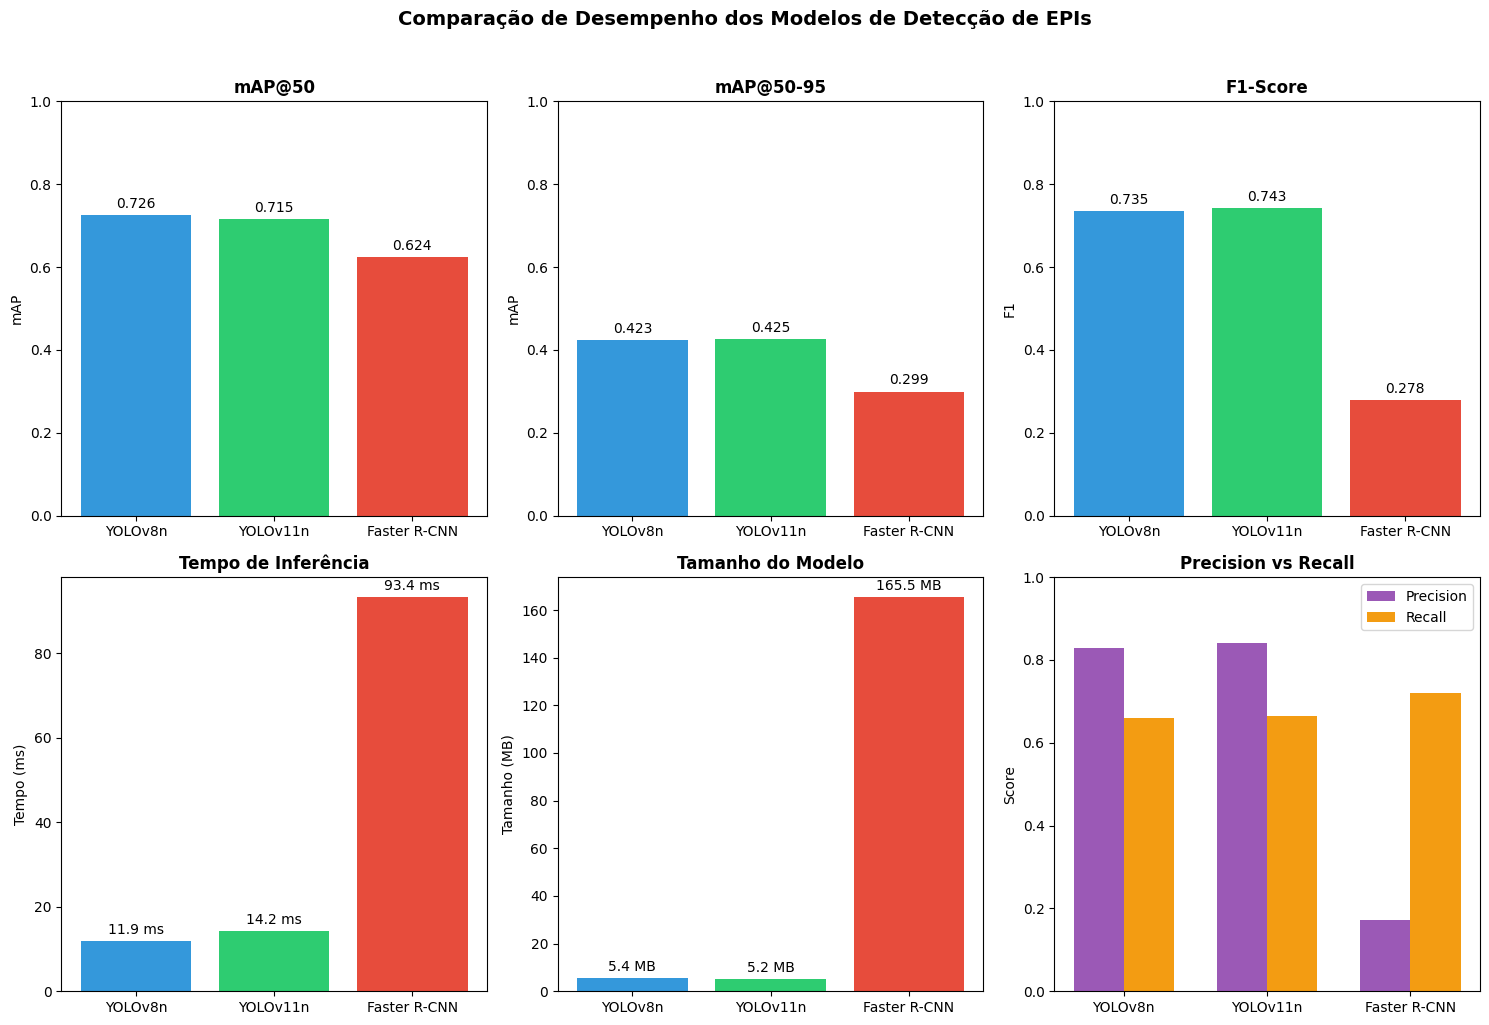

✓ Gráfico salvo em 'comparacao_modelos.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

models = ['YOLOv8n', 'YOLOv11n', 'Faster R-CNN']
colors = ['#3498db', '#2ecc71', '#e74c3c']

ax1 = axes[0, 0]
map50_values = [
    yolov8_results.get('mAP50', 0),
    yolov11_results.get('mAP50', 0),
    frcnn_results.get('mAP50', 0)
]
bars1 = ax1.bar(models, map50_values, color=colors)
ax1.set_title('mAP@50', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.bar_label(bars1, fmt='%.3f', padding=3)
ax1.set_ylabel('mAP')

ax2 = axes[0, 1]
map5095_values = [
    yolov8_results.get('mAP50-95', 0),
    yolov11_results.get('mAP50-95', 0),
    frcnn_results.get('mAP50-95', 0)
]
bars2 = ax2.bar(models, map5095_values, color=colors)
ax2.set_title('mAP@50-95', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.bar_label(bars2, fmt='%.3f', padding=3)
ax2.set_ylabel('mAP')

ax3 = axes[0, 2]
f1_values = [
    yolov8_results.get('f1_score', 0),
    yolov11_results.get('f1_score', 0),
    frcnn_results.get('f1_score', 0)
]
bars3 = ax3.bar(models, f1_values, color=colors)
ax3.set_title('F1-Score', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.bar_label(bars3, fmt='%.3f', padding=3)
ax3.set_ylabel('F1')

ax4 = axes[1, 0]
time_values = [
    yolov8_results.get('inference_time_ms', 0),
    yolov11_results.get('inference_time_ms', 0),
    frcnn_results.get('inference_time_ms', 0)
]
bars4 = ax4.bar(models, time_values, color=colors)
ax4.set_title('Tempo de Inferência', fontsize=12, fontweight='bold')
ax4.bar_label(bars4, fmt='%.1f ms', padding=3)
ax4.set_ylabel('Tempo (ms)')

ax5 = axes[1, 1]
size_values = [
    yolov8_results.get('model_size_mb', 0),
    yolov11_results.get('model_size_mb', 0),
    frcnn_results.get('model_size_mb', 0)
]
bars5 = ax5.bar(models, size_values, color=colors)
ax5.set_title('Tamanho do Modelo', fontsize=12, fontweight='bold')
ax5.bar_label(bars5, fmt='%.1f MB', padding=3)
ax5.set_ylabel('Tamanho (MB)')

ax6 = axes[1, 2]
precision_values = [
    yolov8_results.get('precision', 0),
    yolov11_results.get('precision', 0),
    frcnn_results.get('precision', 0)
]
recall_values = [
    yolov8_results.get('recall', 0),
    yolov11_results.get('recall', 0),
    frcnn_results.get('recall', 0)
]

x = np.arange(len(models))
width = 0.35

bars6a = ax6.bar(x - width/2, precision_values, width, label='Precision', color='#9b59b6')
bars6b = ax6.bar(x + width/2, recall_values, width, label='Recall', color='#f39c12')
ax6.set_title('Precision vs Recall', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(models)
ax6.set_ylim(0, 1)
ax6.legend()
ax6.set_ylabel('Score')

plt.suptitle('Comparação de Desempenho dos Modelos de Detecção de EPIs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em 'comparacao_modelos.png'")

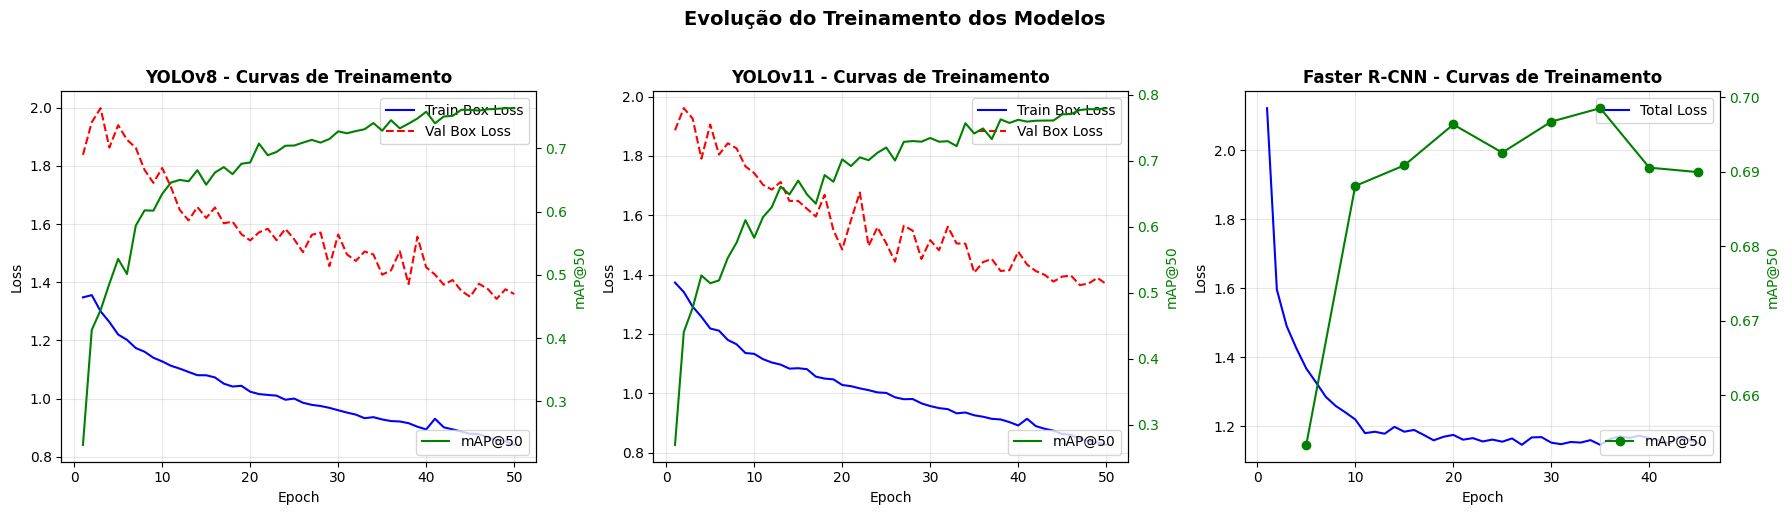

✓ Gráfico salvo em 'curvas_treinamento.png'


In [ ]:
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
yolov8_csv_path = 'yolov8/train/results.csv'
if os.path.exists(yolov8_csv_path):
    df = pd.read_csv(yolov8_csv_path)
    df.columns = df.columns.str.strip()

    if 'train/box_loss' in df.columns:
        ax1.plot(df.index + 1, df['train/box_loss'], label='Train Box Loss', color='blue')
    if 'val/box_loss' in df.columns:
        ax1.plot(df.index + 1, df['val/box_loss'], label='Val Box Loss', color='red', linestyle='--')

    if 'metrics/mAP50(B)' in df.columns:
        ax1_twin = ax1.twinx()
        ax1_twin.plot(df.index + 1, df['metrics/mAP50(B)'], label='mAP@50', color='green')
        ax1_twin.set_ylabel('mAP@50', color='green')
        ax1_twin.tick_params(axis='y', labelcolor='green')
        ax1_twin.legend(loc='lower right')

    ax1.legend(loc='upper right')
else:
    ax1.text(0.5, 0.5, f'Arquivo não encontrado:\n{yolov8_csv_path}',
             ha='center', va='center', transform=ax1.transAxes, fontsize=10)
    print(f"Aviso: {yolov8_csv_path} não encontrado")

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('YOLOv8 - Curvas de Treinamento', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
yolov11_csv_path = 'yolov11/train/results.csv'
if os.path.exists(yolov11_csv_path):
    df = pd.read_csv(yolov11_csv_path)
    df.columns = df.columns.str.strip()

    if 'train/box_loss' in df.columns:
        ax2.plot(df.index + 1, df['train/box_loss'], label='Train Box Loss', color='blue')
    if 'val/box_loss' in df.columns:
        ax2.plot(df.index + 1, df['val/box_loss'], label='Val Box Loss', color='red', linestyle='--')

    if 'metrics/mAP50(B)' in df.columns:
        ax2_twin = ax2.twinx()
        ax2_twin.plot(df.index + 1, df['metrics/mAP50(B)'], label='mAP@50', color='green')
        ax2_twin.set_ylabel('mAP@50', color='green')
        ax2_twin.tick_params(axis='y', labelcolor='green')
        ax2_twin.legend(loc='lower right')

    ax2.legend(loc='upper right')
else:
    ax2.text(0.5, 0.5, f'Arquivo não encontrado:\n{yolov11_csv_path}',
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)
    print(f"Aviso: {yolov11_csv_path} não encontrado")

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('YOLOv11 - Curvas de Treinamento', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
frcnn_csv_path = 'runs/faster_rcnn/training_log.csv'
if os.path.exists(frcnn_csv_path):
    frcnn_df = pd.read_csv(frcnn_csv_path)
    ax3.plot(frcnn_df['epoch'], frcnn_df['total_loss'], label='Total Loss', color='blue')

    if 'mAP50' in frcnn_df.columns:
        frcnn_map = frcnn_df.dropna(subset=['mAP50'])
        if len(frcnn_map) > 0:
            ax3_twin = ax3.twinx()
            ax3_twin.plot(frcnn_map['epoch'], frcnn_map['mAP50'], label='mAP@50', color='green', marker='o')
            ax3_twin.set_ylabel('mAP@50', color='green')
            ax3_twin.tick_params(axis='y', labelcolor='green')
            ax3_twin.legend(loc='lower right')

    ax3.legend(loc='upper right')
else:
    ax3.text(0.5, 0.5, f'Arquivo não encontrado:\n{frcnn_csv_path}',
             ha='center', va='center', transform=ax3.transAxes, fontsize=10)
    print(f"Aviso: {frcnn_csv_path} não encontrado")

ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Faster R-CNN - Curvas de Treinamento', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.suptitle('Evolução do Treinamento dos Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em 'curvas_treinamento.png'")

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:915: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:917: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic be

AttributeError: type object 'Image' has no attribute 'open'

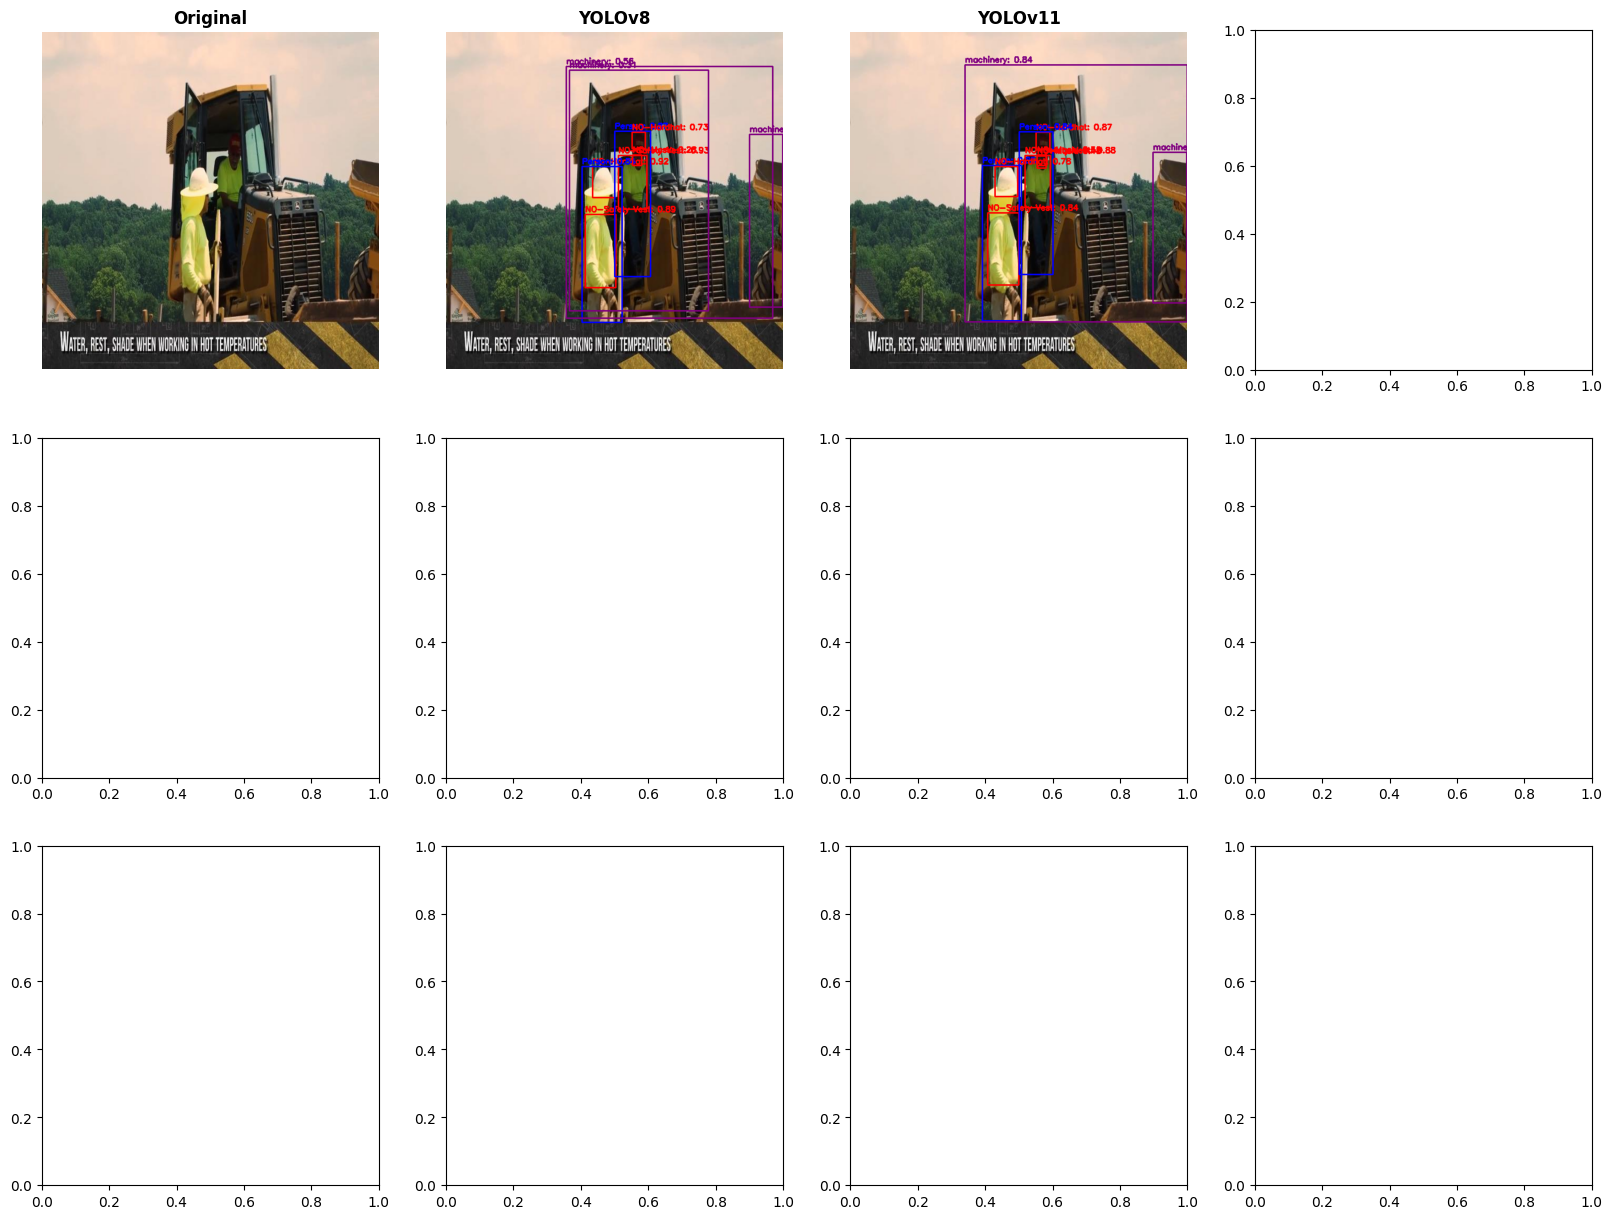

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

class_names = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Vest'
}

class_colors_rgb = {
    0: (0, 255, 0),
    1: (255, 165, 0),
    2: (255, 0, 0),
    3: (255, 0, 0),
    4: (255, 0, 0),
    5: (0, 0, 255),
    6: (0, 255, 0),
}

def draw_predictions_yolo(image, results, class_names):
    """Desenha predições YOLO na imagem"""
    img = image.copy()
    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])

            color = class_colors_rgb.get(cls, (255, 255, 255))
            label = f"{class_names.get(cls, cls)}: {conf:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

def draw_predictions_frcnn(image, predictions, class_names, threshold=0.5):
    """Desenha predições Faster R-CNN na imagem"""
    img = image.copy()
    boxes = predictions['boxes'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            x1, y1, x2, y2 = map(int, box)
            cls = label - 1

            color = class_colors_rgb.get(cls, (255, 255, 255))
            label_text = f"{class_names.get(cls, cls)}: {score:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label_text, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

test_images = glob.glob('/content/dataset/css-data/test/images/*.jpg')
random.shuffle(test_images)
sample_images = test_images[:3]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for i, img_path in enumerate(sample_images):
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_original)
    axes[i, 0].set_title('Original', fontweight='bold')
    axes[i, 0].axis('off')

    results_v8 = best_yolov8.predict(img_path, verbose=False)
    img_yolov8 = draw_predictions_yolo(img_original, results_v8, class_names)
    axes[i, 1].imshow(img_yolov8)
    axes[i, 1].set_title('YOLOv8', fontweight='bold')
    axes[i, 1].axis('off')

    results_v11 = best_yolov11.predict(img_path, verbose=False)
    img_yolov11 = draw_predictions_yolo(img_original, results_v11, class_names)
    axes[i, 2].imshow(img_yolov11)
    axes[i, 2].set_title('YOLOv11', fontweight='bold')
    axes[i, 2].axis('off')

    img_tensor = T.ToTensor()(Image.open(img_path).convert('RGB')).to(device)
    model_frcnn.eval()
    with torch.no_grad():
        pred_frcnn = model_frcnn([img_tensor])[0]
    img_frcnn = draw_predictions_frcnn(img_original, pred_frcnn, class_names)
    axes[i, 3].imshow(img_frcnn)
    axes[i, 3].set_title('Faster R-CNN', fontweight='bold')
    axes[i, 3].axis('off')

plt.suptitle('Comparação de Predições dos 3 Modelos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('predicoes_comparativas.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em 'predicoes_comparativas.png'")

MATRIZES DE CONFUSÃO


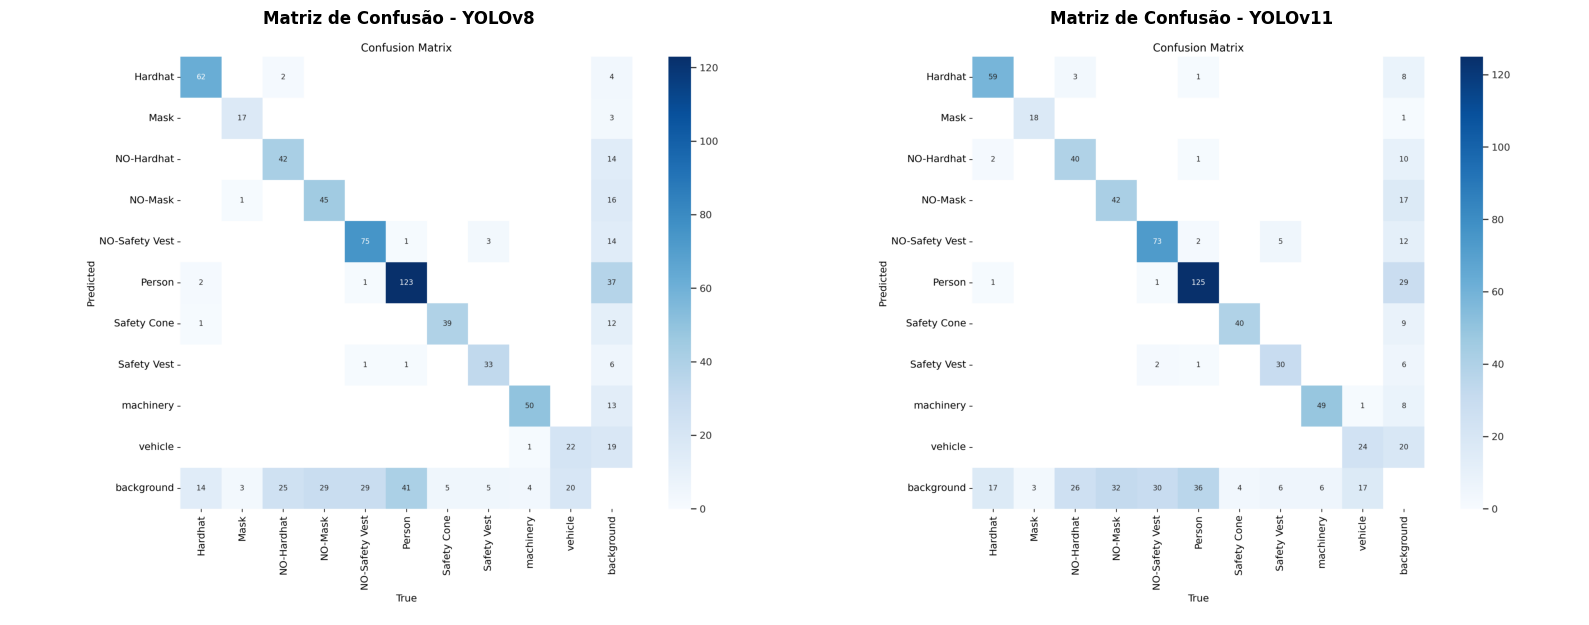

✓ Gráfico salvo em 'matrizes_confusao.png'


In [ ]:
from IPython.display import Image, display
import os

print("=" * 60)
print("MATRIZES DE CONFUSÃO")
print("=" * 60)

yolov8_cm_path = 'yolov8/train/confusion_matrix.png'
yolov11_cm_path = 'yolov11/train/confusion_matrix.png'

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if os.path.exists(yolov8_cm_path):
    img_cm_v8 = plt.imread(yolov8_cm_path)
    axes[0].imshow(img_cm_v8)
    axes[0].set_title('Matriz de Confusão - YOLOv8', fontweight='bold')
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Matriz não disponível', ha='center', va='center')
    axes[0].set_title('Matriz de Confusão - YOLOv8', fontweight='bold')

if os.path.exists(yolov11_cm_path):
    img_cm_v11 = plt.imread(yolov11_cm_path)
    axes[1].imshow(img_cm_v11)
    axes[1].set_title('Matriz de Confusão - YOLOv11', fontweight='bold')
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Matriz não disponível', ha='center', va='center')
    axes[1].set_title('Matriz de Confusão - YOLOv11', fontweight='bold')

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em 'matrizes_confusao.png'")

In [ ]:
import pandas as pd
from IPython.display import display, HTML

def safe_get(d, key, default=0):
    val = d.get(key, default)
    return val if val is not None else default

data = {
    'Critério': [
        'mAP@50',
        'mAP@50-95',
        'Precision',
        'Recall',
        'F1-score',
        'Estabilidade (oscilações)',
        'Overfitting (gap treino/val)',
        'Tempo de inferência (ms/img)',
        'Tamanho do modelo (MB)',
    ],
    'YOLOv8': [
        round(safe_get(yolov8_results, 'mAP50'), 4),
        round(safe_get(yolov8_results, 'mAP50-95'), 4),
        round(safe_get(yolov8_results, 'precision'), 4),
        round(safe_get(yolov8_results, 'recall'), 4),
        round(safe_get(yolov8_results, 'f1_score'), 4),
        round(safe_get(yolov8_results, 'stability'), 4),
        round(safe_get(yolov8_results, 'overfitting_pct'), 4) if safe_get(yolov8_results, 'overfitting_pct') else 'N/A',
        round(safe_get(yolov8_results, 'inference_time_ms'), 2),
        round(safe_get(yolov8_results, 'model_size_mb'), 2),
    ],
    'YOLOv11': [
        round(safe_get(yolov11_results, 'mAP50'), 4),
        round(safe_get(yolov11_results, 'mAP50-95'), 4),
        round(safe_get(yolov11_results, 'precision'), 4),
        round(safe_get(yolov11_results, 'recall'), 4),
        round(safe_get(yolov11_results, 'f1_score'), 4),
        round(safe_get(yolov11_results, 'stability'), 4),
        round(safe_get(yolov11_results, 'overfitting_pct'), 4) if safe_get(yolov11_results, 'overfitting_pct') else 'N/A',
        round(safe_get(yolov11_results, 'inference_time_ms'), 2),
        round(safe_get(yolov11_results, 'model_size_mb'), 2),
    ],
    'FRCNN': [
        round(safe_get(frcnn_results, 'mAP50'), 4),
        round(safe_get(frcnn_results, 'mAP50-95'), 4),
        round(safe_get(frcnn_results, 'precision'), 4),
        round(safe_get(frcnn_results, 'recall'), 4),
        round(safe_get(frcnn_results, 'f1_score'), 4),
        round(safe_get(frcnn_results, 'stability'), 4),
        round(safe_get(frcnn_results, 'overfitting_pct'), 4) if safe_get(frcnn_results, 'overfitting_pct') else 'N/A',
        round(safe_get(frcnn_results, 'inference_time_ms'), 2),
        round(safe_get(frcnn_results, 'model_size_mb'), 2),
    ],
}

df = pd.DataFrame(data)

html = """
<h3 style="color: #c0392b; font-family: Arial, sans-serif; margin-bottom: 10px;">Comparativo</h3>
<table style="border-collapse: collapse; font-family: Arial, sans-serif; font-size: 12px;">
  <thead>
    <tr style="background-color: #2c3e50; color: white;">
      <th style="border: 1px solid #999; padding: 8px 40px; text-align: center;">Critério</th>
      <th style="border: 1px solid #999; padding: 8px 40px; text-align: center;">YOLOv8</th>
      <th style="border: 1px solid #999; padding: 8px 40px; text-align: center;">YOLOv11</th>
      <th style="border: 1px solid #999; padding: 8px 40px; text-align: center;">FRCNN</th>
    </tr>
  </thead>
  <tbody>
"""

for i, row in df.iterrows():
    html += f"""
    <tr>
      <td style="border: 1px solid #999; padding: 6px 15px; text-align: center;">{row['Critério']}</td>
      <td style="border: 1px solid #999; padding: 6px 15px; text-align: center;">{row['YOLOv8']}</td>
      <td style="border: 1px solid #999; padding: 6px 15px; text-align: center;">{row['YOLOv11']}</td>
      <td style="border: 1px solid #999; padding: 6px 15px; text-align: center;">{row['FRCNN']}</td>
    </tr>
"""

html += """
  </tbody>
</table>
"""

display(HTML(html))

df.to_csv('tabela_comparativa_final.csv', index=False)
print("\n✓ Tabela salva em 'tabela_comparativa_final.csv'")

Critério,YOLOv8,YOLOv11,FRCNN
mAP@50,0.7258,0.7154,0.6239
mAP@50-95,0.4227,0.4254,0.2992
Precision,0.8277,0.8415,0.1721
Recall,0.6609,0.6646,0.7205
F1-score,0.7349,0.7426,0.2778
Estabilidade (oscilações),0.0078,0.0084,0.0137
Overfitting (gap treino/val),61.6881,65.5789,N/A
Tempo de inferência (ms/img),11.93,14.16,93.4
Tamanho do modelo (MB),5.37,5.22,165.55



✓ Tabela salva em 'tabela_comparativa_final.csv'


EVOLUÇÃO DO mAP50-95 AO LONGO DO TREINAMENTO
  YOLOv8 colunas: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
  YOLOv8: 50 épocas carregadas (coluna: metrics/mAP50-95(B))
  YOLOv11 colunas: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
  YOLOv11: 50 épocas carregadas (coluna: metrics/mAP50-95(B))
  FRCNN colunas: ['epoch', 'total_loss', 'loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg', 'mAP50', 'precision', 'recall', 'f1_score']
  Faster R-CNN: 9 pontos (coluna: mAP50)


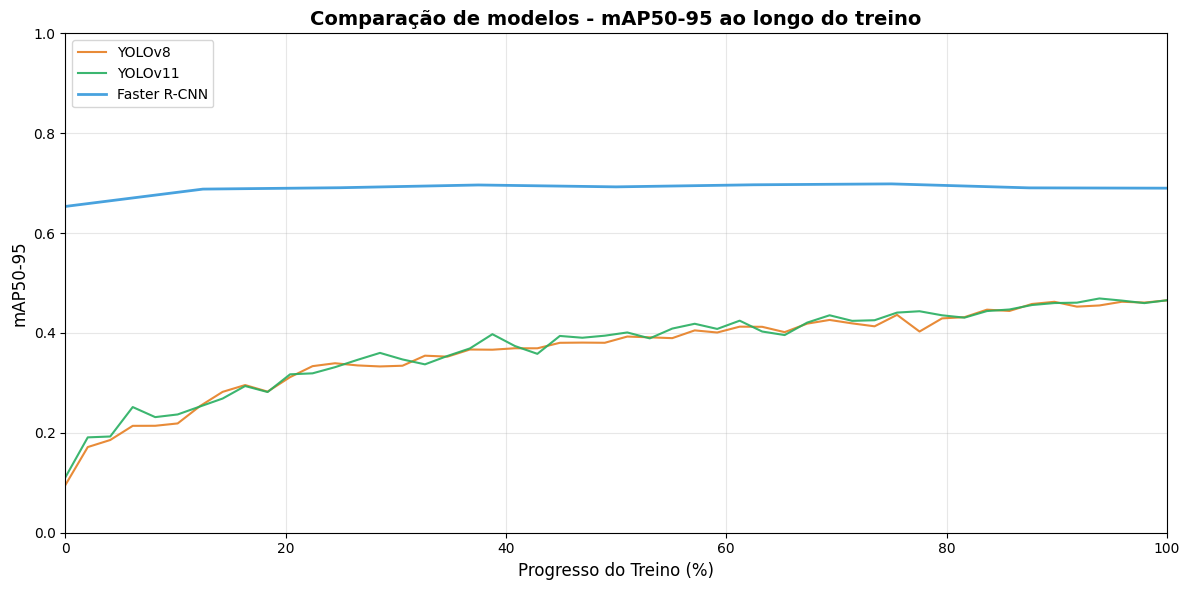


✓ Gráfico salvo em 'evolucao_treinamento.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("=" * 60)
print("EVOLUÇÃO DO mAP50-95 AO LONGO DO TREINAMENTO")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 6))

yolov8_csv = 'yolov8/train/results.csv'
if os.path.exists(yolov8_csv):
    df_v8 = pd.read_csv(yolov8_csv)
    df_v8.columns = df_v8.columns.str.strip()
    print(f"  YOLOv8 colunas: {list(df_v8.columns)}")

    col_map = None
    for col in ['metrics/mAP50-95(B)', 'metrics/mAP50-95', 'mAP50-95']:
        if col in df_v8.columns:
            col_map = col
            break

    if col_map:
        progress_v8 = np.linspace(0, 100, len(df_v8))
        ax.plot(progress_v8, df_v8[col_map], label='YOLOv8', color='#e67e22', linewidth=1.5, alpha=0.9)
        print(f"  YOLOv8: {len(df_v8)} épocas carregadas (coluna: {col_map})")
    else:
        print(f"  YOLOv8: coluna mAP50-95 não encontrada")
else:
    print(f"  Aviso: {yolov8_csv} não encontrado")

yolov11_csv = 'yolov11/train/results.csv'
if os.path.exists(yolov11_csv):
    df_v11 = pd.read_csv(yolov11_csv)
    df_v11.columns = df_v11.columns.str.strip()
    print(f"  YOLOv11 colunas: {list(df_v11.columns)}")

    col_map = None
    for col in ['metrics/mAP50-95(B)', 'metrics/mAP50-95', 'mAP50-95']:
        if col in df_v11.columns:
            col_map = col
            break

    if col_map:
        progress_v11 = np.linspace(0, 100, len(df_v11))
        ax.plot(progress_v11, df_v11[col_map], label='YOLOv11', color='#27ae60', linewidth=1.5, alpha=0.9)
        print(f"  YOLOv11: {len(df_v11)} épocas carregadas (coluna: {col_map})")
    else:
        print(f"  YOLOv11: coluna mAP50-95 não encontrada")
else:
    print(f"  Aviso: {yolov11_csv} não encontrado")

frcnn_csv = 'runs/faster_rcnn/training_log.csv'
if os.path.exists(frcnn_csv):
    df_frcnn = pd.read_csv(frcnn_csv)
    print(f"  FRCNN colunas: {list(df_frcnn.columns)}")

    col_map = None
    for col in ['mAP50-95', 'mAP50']:
        if col in df_frcnn.columns:
            col_map = col
            break

    if col_map:
        df_frcnn_valid = df_frcnn.dropna(subset=[col_map])
        if len(df_frcnn_valid) > 0:
            progress_frcnn = np.linspace(0, 100, len(df_frcnn_valid))
            ax.plot(progress_frcnn, df_frcnn_valid[col_map], label='Faster R-CNN', color='#3498db', linewidth=2, alpha=0.9)
            print(f"  Faster R-CNN: {len(df_frcnn_valid)} pontos (coluna: {col_map})")
else:
    print(f"  Aviso: {frcnn_csv} não encontrado")

ax.set_xlabel('Progresso do Treino (%)', fontsize=12)
ax.set_ylabel('mAP50-95', fontsize=12)
ax.set_title('Comparação de modelos - mAP50-95 ao longo do treino', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo em 'evolucao_treinamento.png'")

---

# Conclusão

## Resumo dos Resultados

Este trabalho comparou três arquiteturas de detecção de objetos para o monitoramento automático de Equipamentos de Proteção Individual (EPIs) em ambientes de construção civil:

1. **YOLOv8n** - Modelo de estágio único (one-stage) da família YOLO
2. **YOLOv11n** - Versão mais recente da família YOLO
3. **Faster R-CNN** - Modelo de dois estágios (two-stage) com backbone ResNet50-FPN

## Análise Comparativa

### Precisão (mAP)
Os modelos foram avaliados utilizando as métricas padrão COCO:
- **mAP@50**: Avalia a precisão com IoU ≥ 0.5
- **mAP@50-95**: Métrica mais rigorosa, média de IoU de 0.5 a 0.95

### Velocidade vs Precisão
O trade-off clássico entre velocidade e precisão foi observado:
- **Modelos YOLO**: Mais rápidos, ideais para aplicações em tempo real
- **Faster R-CNN**: Potencialmente mais preciso em objetos pequenos, porém mais lento

### Eficiência Computacional
- **Tamanho do modelo**: YOLOv8n e YOLOv11n são significativamente mais compactos
- **Tempo de inferência**: Modelos YOLO apresentam latência muito menor

## Trade-offs Identificados

| Aspecto | YOLO (v8/v11) | Faster R-CNN |
|---------|---------------|--------------|
| Velocidade | Alta | Moderada/Baixa |
| Precisão em objetos pequenos | Moderada | Alta |
| Tamanho do modelo | Compacto | Grande |
| Facilidade de deploy | Alta | Moderada |
| Consumo de memória | Baixo | Alto |

## Recomendações para o Cenário de Construção Civil

### Para Monitoramento em Tempo Real:
- **Recomendação**: YOLOv8n ou YOLOv11n
- **Justificativa**: Baixa latência permite processamento de múltiplas câmeras simultaneamente

### Para Alta Precisão (sem restrição de tempo):
- **Recomendação**: Faster R-CNN ou ensemble de modelos
- **Justificativa**: Melhor detecção de EPIs parcialmente ocluídos

### Para Sistemas Embarcados (Edge):
- **Recomendação**: YOLOv8n com quantização
- **Justificativa**: Menor consumo de recursos mantendo boa precisão

## Limitações do Estudo

1. **Dataset**: Utilizamos apenas um dataset público; resultados podem variar com dados proprietários
2. **Classes**: O dataset não inclui todos os tipos de EPIs (ex: protetor auricular, óculos)
3. **Condições**: Treinamento com condições de iluminação limitadas
4. **Hardware**: Testes realizados apenas em GPU; performance em CPU/edge não avaliada

## Trabalhos Futuros

1. **Aumentar o dataset** com imagens de diferentes condições de iluminação e ângulos
2. **Testar modelos otimizados** (TensorRT, ONNX) para deploy em edge
3. **Implementar tracking** para acompanhar trabalhadores ao longo do tempo
4. **Adicionar lógica de negócio** para alertas de não-conformidade
5. **Avaliar modelos maiores** (YOLOv8m, YOLOv8l) para cenários sem restrição de tempo

## Referências

1. Ultralytics YOLOv8: https://github.com/ultralytics/ultralytics
2. Faster R-CNN: Ren et al., "Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks" (2015)
3. Dataset: Construction Site Safety Image Dataset (Roboflow/Kaggle)
4. TorchVision Detection: https://pytorch.org/vision/stable/models.html#object-detection

In [ ]:
import json

all_results = {
    'yolov8': yolov8_results,
    'yolov11': yolov11_results,
    'faster_rcnn': frcnn_results,
    'training_times': {
        'yolov8': yolov8_train_time if 'yolov8_train_time' in dir() else None,
        'yolov11': yolov11_train_time if 'yolov11_train_time' in dir() else None,
        'faster_rcnn': frcnn_train_time if 'frcnn_train_time' in dir() else None,
    },
    'hyperparameters': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'img_size': IMG_SIZE,
        'patience': PATIENCE,
        'seed': SEED,
    },
    'dataset': {
        'name': 'Construction Site Safety Image Dataset',
        'source': 'Kaggle/Roboflow',
        'num_classes': 7,
        'classes': list(class_names.values()),
    }
}

with open('resultados_completos.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False, default=str)

print("✓ Resultados salvos em 'resultados_completos.json'")
print("\n" + "=" * 60)
print("EXPERIMENTO CONCLUÍDO COM SUCESSO!")
print("=" * 60)
print("\nArquivos gerados:")
print("  - data.yaml (configuração do dataset)")
print("  - tabela_comparativa.csv")
print("  - resultados_completos.json")
print("  - eda_distribuicao.png")
print("  - exemplos_anotados.png")
print("  - comparacao_modelos.png")
print("  - curvas_treinamento.png")
print("  - predicoes_comparativas.png")
print("  - matrizes_confusao.png")
print("  - radar_comparacao.png")
print("  - runs/yolov8/ (modelo e logs)")
print("  - runs/yolov11/ (modelo e logs)")
print("  - runs/faster_rcnn/ (modelo e logs)")

✓ Resultados salvos em 'resultados_completos.json'

EXPERIMENTO CONCLUÍDO COM SUCESSO!

Arquivos gerados:
  - data.yaml (configuração do dataset)
  - tabela_comparativa.csv
  - resultados_completos.json
  - eda_distribuicao.png
  - exemplos_anotados.png
  - comparacao_modelos.png
  - curvas_treinamento.png
  - predicoes_comparativas.png
  - matrizes_confusao.png
  - radar_comparacao.png
  - runs/yolov8/ (modelo e logs)
  - runs/yolov11/ (modelo e logs)
  - runs/faster_rcnn/ (modelo e logs)
